# Assignment 1
**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, RNNs, Transformers, Huggingface



# Contact
For any doubt, question, issue or help, you can always contact us at the following email addresses:

Teaching Assistants:

- Federico Ruggeri -> federico.ruggeri6@unibo.it
- Eleonora Mancini -> e.mancini@unibo.it

Professor:
- Paolo Torroni -> p.torroni@unibo.it

# Introduction
You are asked to address the [EXIST 2023 Task 2](https://clef2023.clef-initiative.eu/index.php?page=Pages/labs.html#EXIST) on sexism detection.

## Problem Definition

This task aims to categorize the sexist messages according to the intention of the author in one of the following categories: (i) direct sexist message, (ii) reported sexist message and (iii) judgemental message.

### Examples:

#### DIRECT 
The intention was to write a message that is sexist by itself or incites to be sexist, as in:

''*A woman needs love, to fill the fridge, if a man can give this to her in return for her services (housework, cooking, etc), I don’t see what else she needs.*''

#### REPORTED
The intention is to report and share a sexist situation suffered by a woman or women in first or third person, as in:

''*Today, one of my year 1 class pupils could not believe he’d lost a race against a girl.*''

#### JUDGEMENTAL
The intention was to judge, since the tweet describes sexist situations or behaviours with the aim of condemning them.

''*As usual, the woman was the one quitting her job for the family’s welfare…*''

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"



import tensorflow as tf

tf.config.set_visible_devices([], 'GPU')

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


In [2]:
# Package requirements
! pip install --upgrade pip
! pip install tqdm pandas nltk gensim numpy tensorflow matplotlib scikit-learn
! pip install torch torchvision torchaudio
! pip install transformers datasets bitsandbytes accelerate 

In [3]:
# Standard library
import os
import re
import json
import gc
import random
from collections import Counter, defaultdict

# Typing
from typing import List, Dict, Tuple, Set

# Third-party libraries
import numpy as np
import pandas as pd
import gensim
import gensim.downloader as gloader
import nltk
from nltk import pos_tag, word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
#from datasets import Dataset
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras.callbacks import EarlyStopping, Callback
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adam


# [Task 1 - 1.0 points] Corpus

We have preparared a small version of EXIST dataset in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data).

Check the `A1/data` folder. It contains 3 `.json` files representing `training`, `validation` and `test` sets.


### Dataset Description
- The dataset contains tweets in both English and Spanish.
- There are labels for multiple tasks, but we are focusing on **Task 2**.
- For Task 2, labels are assigned by six annotators.
- The labels for Task 2 represent whether the tweet is non-sexist ('-') or its sexist intention ('DIRECT', 'REPORTED', 'JUDGEMENTAL').







### Example

```
    "203260": {
        "id_EXIST": "203260",
        "lang": "en",
        "tweet": "ik when mandy says “you look like a whore” i look cute as FUCK",
        "number_annotators": 6,
        "annotators": ["Annotator_473", "Annotator_474", "Annotator_475", "Annotator_476", "Annotator_477", "Annotator_27"],
        "gender_annotators": ["F", "F", "M", "M", "M", "F"],
        "age_annotators": ["18-22", "23-45", "18-22", "23-45", "46+", "46+"],
        "labels_task1": ["YES", "YES", "YES", "NO", "YES", "YES"],
        "labels_task2": ["DIRECT", "DIRECT", "REPORTED", "-", "JUDGEMENTAL", "REPORTED"],
        "labels_task3": [
          ["STEREOTYPING-DOMINANCE"],
          ["OBJECTIFICATION"],
          ["SEXUAL-VIOLENCE"],
          ["-"],
          ["STEREOTYPING-DOMINANCE", "OBJECTIFICATION"],
          ["OBJECTIFICATION"]
        ],
        "split": "TRAIN_EN"
      }
    }
```

### Instructions
1. **Download** the `A1/data` folder.
2. **Load** the three JSON files and encode them as ``pandas.DataFrame``.
3. **Aggregate labels** for Task 2 using majority voting and store them in a new dataframe column called `label`. Items without a clear majority will be removed from the dataset.
4. **Filter the DataFrame** to keep only rows where the `lang` column is `'en'`.
5. **Remove unwanted columns**: Keep only `id_EXIST`, `lang`, `tweet`, and `label`.
6. **Encode the `label` column**: Use the following mapping

```
{
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}
```

In [4]:
! rm -rf nlp-course-material
! git clone https://github.com/nlp-unibo/nlp-course-material.git

Cloning into 'nlp-course-material'...
remote: Enumerating objects: 424, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 424 (delta 0), reused 2 (delta 0), pack-reused 418 (from 1)
Receiving objects: 100% (424/424), 8.83 MiB | 14.63 MiB/s, done.
Resolving deltas: 100% (190/190), done.


In [5]:
# Load and encode the jsons
data_path = "./nlp-course-material/2025-2026/Assignment 1/data/"
train_df = pd.read_json(data_path + 'training.json').T
test_df = pd.read_json(data_path + 'test.json').T
val_df = pd.read_json(data_path + 'validation.json').T
dfs = [train_df, val_df, test_df]

print("Before:", train_df.shape, val_df.shape, test_df.shape)

for i, df in enumerate(dfs):
    # Aggregate labels by majority vote, only keep rows with unique majority
    majority_labels = []
    for labels in df["labels_task2"]:
        c = Counter(labels).most_common(2)
        if len(c)==1:
            majority_labels.append(c[0][0])
        elif c[1][1] < c[0][1]:
            majority_labels.append(c[0][0])
        else:
            majority_labels.append(None)
    df["label"] = majority_labels
    df = df.dropna(subset=["label"]).reset_index(drop=True)

    # Filter rows with language "en"
    df = df[df["lang"]=="en"].reset_index(drop=True)
    df = df[["id_EXIST", "lang", "tweet", "label"]]

    # Encode labels as integers
    label_mapping = {"-":0, "DIRECT":1, "JUDGEMENTAL":2, "REPORTED":3}
    reverse_mapping = {v: k for k, v in label_mapping.items()}  # useful for task 6
    df["label"] = df["label"].map(label_mapping)

    dfs[i] = df # NOTE: we have to do this otherwise the changes won't persist

train_df, val_df, test_df = dfs
print("After: ", train_df.shape, val_df.shape, test_df.shape)

Before: (6920, 11) (726, 11) (312, 11)
After:  (2873, 4) (150, 4) (280, 4)


# [Task2 - 0.5 points] Data Cleaning
In the context of tweets, we have noisy and informal data that often includes unnecessary elements like emojis, hashtags, mentions, and URLs. These elements may interfere with the text analysis.



### Instructions
- **Remove emojis** from the tweets.
- **Remove hashtags** (e.g., `#example`).
- **Remove mentions** such as `@user`.
- **Remove URLs** from the tweets.
- **Remove special characters and symbols**.
- **Remove specific quote characters** (e.g., curly quotes).
- **Perform lemmatization** to reduce words to their base form.

In [6]:
# Download required NLTK data
# NOTE: this is mostly from the lab, mayeb it's not the most efficient way
os.makedirs("nltk_data", exist_ok=True)
nltk.download('omw-1.4', download_dir="./nltk_data")
nltk.download('wordnet', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger_eng', download_dir="./nltk_data")
nltk.download('punkt_tab', download_dir="./nltk_data")
nltk.data.path.append("./nltk_data")

lemmatizer = WordNetLemmatizer()

def pos2wordnet_tag(treebank_tag: str) -> str:
    match treebank_tag[0]:
        case "J":   return wordnet.ADJ
        case "V":   return wordnet.VERB
        case "N":   return wordnet.NOUN
        case "R":   return wordnet.ADV
        case _:     return wordnet.NOUN

def token_lemma(text: str, no_lemma: bool=False) -> str:
    """
    Tokenize the text, then lemmatize the tokens and then merge the lemmatized tokens into a text
    """
    tokens = word_tokenize(text)    # uses recommended NLTK tokenizer
    if no_lemma: 
        return " ".join(tokens)
    tagged_tokens = pos_tag(tokens)
    lemmatized_tokens = [
        lemmatizer.lemmatize(tok.lower(), pos2wordnet_tag(pos))
        for tok, pos in tagged_tokens
    ]
    return " ".join(lemmatized_tokens)

def clean_lemm_text(text, patterns, no_lemma: bool=False):
    
    # Remove other patterns
    # NOTE: we replace chars with space to avoid merging words during the process, the tokenizer will take care of extra spaces.
    for pattern in patterns:
        text = pattern.sub(' ', text) 
    
    # Tokenize, lemmatize and merge
    return token_lemma(text, no_lemma=no_lemma)

[nltk_data] Downloading package omw-1.4 to ./nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to ./nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to ./nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [7]:
# NOTE: we changed the order of patterns with respect to instructions so that some could be simplified
patterns = [
    
    # Hashtags
    re.compile(r'#\w+'),
    
    # Mentions
    re.compile(r'@\w+'),
    
    # URLs
    re.compile(r'https?://[^\s]+'), 
    
    # Emojis, special characters and symbols, specific quotes characters
    # NOTE: we asked the tutors as it was ambiguous and they said they meant all non-alphanumeric characters so we merged them.
    re.compile(r'[^\s\w]')
    
]

for i, df in enumerate(dfs):
    df['cleaned_lemm_tweet'] = df["tweet"].apply(
        lambda text: clean_lemm_text(text, patterns)
    )
    
    # Useful for task 6
    df['cleaned_only_tweet'] = df["tweet"].apply(
        lambda text: clean_lemm_text(text, patterns, no_lemma=True)
    )
    
    # TODO: only for train set, maybe apply more complex cleaning:
    # 1) remove noisy chars due to simple removal
    # 2) MAYBE: html tags, mnore complex and noisy patterns (es. 10%-)
    if i==0: 
        pass
        
    dfs[i] = df    

display(train_df[["tweet", "cleaned_lemm_tweet", "cleaned_only_tweet"]])

,tweet,cleaned_lemm_tweet,cleaned_only_tweet
0,FFS! How about laying the blame on the bastard...,ffs how about lay the blame on the bastard who...,FFS How about laying the blame on the bastard ...
1,Writing a uni essay in my local pub with a cof...,write a uni essay in my local pub with a coffe...,Writing a uni essay in my local pub with a cof...
2,@UniversalORL it is 2021 not 1921. I dont appr...,it be 2021 not 1921 i dont appreciate that on ...,it is 2021 not 1921 I dont appreciate that on ...
3,@GMB this is unacceptable. Use her title as yo...,this be unacceptable use her title a you do fo...,this is unacceptable Use her title as you did ...
4,‘Making yourself a harder target’ basically bo...,make yourself a hard target basically boil dow...,Making yourself a harder target basically boil...
...,...,...,...
2868,@ShefVaidya Ma'am if I say that you look like ...,ma be if i say that you look like a whore woul...,Ma am if I say that you look like a whore Woul...
2869,idk why y’all bitches think having half your a...,idk why y all bitch think have half your as ha...,idk why y all bitches think having half your a...
2870,This has been a part of an experiment with @Wo...,this have be a part of an experiment with what...,This has been a part of an experiment with Wha...
2871,"""Take me already"" ""Not yet. You gotta be ready...",take me already not yet you get ta be ready i ...,Take me already Not yet You got ta be ready I ...


In [8]:
from typing import Tuple, Set


def extract_corpus(df: pd.DataFrame) -> Tuple[List[List[str]], Set[str]]:
    # NOTE: we use split as they were already tokenized and jointed with spaces
    corpus = df["cleaned_lemm_tweet"].apply(lambda x: x.split()).tolist()
    unique_words = {word for sentence in corpus for word in sentence}
    return corpus, unique_words

# Extract corpora
train_corpus, train_words = extract_corpus(train_df)
val_corpus, val_words = extract_corpus(val_df)
test_corpus, test_words = extract_corpus(test_df)

# [Task 3 - 0.5 points] Text Encoding
To train a neural sexism classifier, you first need to encode text into numerical format.




### Instructions

* Embed words using **GloVe embeddings**.
* You are **free** to pick any embedding dimension.





### What about OOV tokens?
   * All the tokens in the **training** set that are not in GloVe **must** be added to the vocabulary.
   * For the remaining tokens (i.e., OOV in the validation and test sets), you have to assign them a **special token** (e.g., ``<UNK>``) and a **static** embedding.
   * You are **free** to define the static embedding using any strategy (e.g., random, neighbourhood, etc...)



### More about OOV

For a given token:

* **If in train set**: add to vocabulary and assign an embedding (use GloVe if token in GloVe, custom embedding otherwise).
* **If in val/test set**: assign special token if not in vocabulary and assign custom embedding.

Your vocabulary **should**:

* Contain all tokens in train set; or
* Union of tokens in train set and in GloVe $\rightarrow$ we make use of existing knowledge!

In [9]:
# Hyperparams
USE_FULL_PRELOAD_EMB_MODEL = False
EMBEDDING_DIMENSION = 50
OOV_TOKEN = "<OOV>"
SEED=42

In [52]:
def load_embedding_model(
    model_type: str,
    embedding_dimension: int = 50
) -> gensim.models.keyedvectors.KeyedVectors:
    
    """
    Load pre-trained embedding model (Word2Vec, GloVe, FastText).

    :param model_type: 'word2vec', 'glove', or 'fasttext'
    :param embedding_dimension: embedding size (only used for GloVe)
    :return: gensim KeyedVectors object
    """
    
    types = {
        "word2vec" : "word2vec-google-news-300",
        "glove" : f"glove-wiki-gigaword-{embedding_dimension}",
        "fasttext" : "fasttext-wiki-news-subwords-300"
    }
    
    model_type_lower = model_type.strip().lower()
    if model_type_lower not in types.keys():
        raise ValueError(f"Unsupported embedding model type. Use {', '.join(list(types.keys()))}")
    else:
        path = types[model_type_lower]
        
    try:
        return gloader.load(path)
    except ValueError as e:
        raise ValueError("Failed to load embedding. Check dimension compatibility.") from e
        
def build_tokenizer(
    train_words: Set[str] = None,
    embedding_model: gensim.models.keyedvectors.KeyedVectors = None,
    use_full_embed_model: bool = True,
    oov_token: str = "<OOV>",
    verbose: bool = False,
) -> Tokenizer:
    """
    Build a Keras tokenizer from a corpus of tokenized sentences.
    
    :param train_words: set of words in training corpus (used when use_full_embed_model=False)
    :param embedding_model: pre-trained embedding model (used when use_full_embed_model=True)
    :param use_full_embed_model: if True, use all words from corpus + embedding_model; if False, only train_words
    :param oov_token: token for out-of-vocabulary words
    :param verbose: print statistics
    :return: fitted Tokenizer
    """
    
    assert isinstance(train_words, set), "train_words must be a set of strings"
    
    # Determine which words to keep
    embedding_words = set(embedding_model.index_to_key)
    if use_full_embed_model:
        # Use all words from embedding model and training corpus
        vocab_to_use = train_words | embedding_words  # Union
    else:
        # Only use training words
        vocab_to_use = train_words
    
    # Build tokenizer
    # NOTE: we load the glove tokens as they are (with punctuation, case-sensitive)
    tokenizer = Tokenizer(
        oov_token=oov_token,
        filters='',           
        lower=False,          
        split=' '             
    )
    tokenizer.fit_on_texts(list(vocab_to_use))
    
    if verbose and not use_full_embed_model:
        print(f"Tokenizer doesn't contain {len(embedding_words - train_words)} words from the embedding model (they were not in the train set).")
    
    return tokenizer

def build_embedding_matrix(
    tokenizer: Tokenizer,
    embedding_model: gensim.models.keyedvectors.KeyedVectors,
    seed: int = 42,
    verbose: bool = True,
    totally_random=False
) -> tuple[np.ndarray, list]:
    """
    Build embedding matrix from tokenizer vocabulary and embedding model.
    
    Index 0: padding (zeros)
    Other indices: 
        - If word in embedding_model: use pre-trained embedding
        - Otherwise: random embedding based on distribution of train_words in model
    
    :param tokenizer: fitted Keras tokenizer
    :param embedding_model: pre-loaded embedding model (unchanged)
    :param train_words: set of words in training corpus (for computing random embedding distribution)
    :param seed: random seed for reproducibility
    :param verbose: whether to print detailed statistics
    :return: tuple of (embedding_matrix, random_idxs)
             embedding_matrix: shape (vocab_size, embedding_dim)
             random_idxs: list of indices that got random embeddings
    """
    vocab_size = len(tokenizer.word_index) + 1
    embedding_dim = embedding_model.vector_size
    
    # Initialize with zeros
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    # Pre-compute parameters for random embeddings
    # ALWAYS use distribution from the tokenizer (only train or train|model)
    filtered_vectors = np.array([
        embedding_model[word] for word in tokenizer.word_index.keys() 
        if word in embedding_model
    ])
    mean = filtered_vectors.mean(axis=0)
    std = filtered_vectors.std(axis=0)

    # Statistics tracking
    from_model_count = 0
    random_idxs = []  # indices that received random embeddings
    
    # Set random seed for reproducibility
    np.random.seed(seed)
    
    # Fill embedding matrix with progress bar
    for word, idx in tqdm(tokenizer.word_index.items(), 
                          desc="Building embedding matrix",
                          disable=not verbose):
        if word in embedding_model and not totally_random:
            # Use pre-trained embedding
            embedding_matrix[idx] = embedding_model[word]
            from_model_count += 1
        else:
            # OOV word: use random embedding
            embedding_matrix[idx] = np.random.normal(mean, std)
            random_idxs.append(idx)
    
    if verbose:
        total_words = vocab_size - 1  # excluding padding
        coverage = from_model_count / total_words * 100 if total_words > 0 else 0
        
        print(f"Embedding Matrix Statistics:")
        print(f"\tShape: {embedding_matrix.shape}")
        print(f"\tWords from embedding model: {from_model_count}/{total_words} ({coverage:.2f}%)")
        print(f"\tRandom embeddings (OOV): {len(random_idxs)}")
    
    return embedding_matrix, random_idxs

In [53]:
# Load embedding model
embedding_model = load_embedding_model("glove", EMBEDDING_DIMENSION)
print(f"Embedding model length: {len(embedding_model.index_to_key)}\n")

# Build tokenizer
tokenizer = build_tokenizer(
    train_words=train_words,
    embedding_model=embedding_model,
    use_full_embed_model=USE_FULL_PRELOAD_EMB_MODEL,
    oov_token=OOV_TOKEN,
    verbose=True
)
vocab_size = len(tokenizer.word_index) + 1 # +1 for padding at index 0
print(f"Final vocabulary size: {vocab_size}\n")

# Build embedding matrix
embedding_matrix, random_idxs = build_embedding_matrix(
    tokenizer=tokenizer,
    embedding_model=embedding_model,
    seed=SEED,
    verbose=True
)

Embedding model length: 400000

Tokenizer doesn't contain 391818 words from the embedding model (they were not in the train set).
Final vocabulary size: 9146



Building embedding matrix: 100%|██████████| 9145/9145 [00:00<00:00, 398505.07it/s]

Embedding Matrix Statistics:
	Shape: (9146, 50)
	Words from embedding model: 8182/9145 (89.47%)
	Random embeddings (OOV): 963


## Extra: statistics of OOV in val and test sets

In [12]:
def compute_oov_stats(tokenizer, word_set, set_name):
    """
    Compute out-of-vocabulary statistics for a given word set.
    
    :param tokenizer: fitted Keras tokenizer
    :param word_set: set of words to check
    :param set_name: name of the dataset (for display)
    """
    tokenizer_vocab = set(tokenizer.word_index.keys())
    
    oov_words = word_set - tokenizer_vocab
    in_vocab_words = word_set & tokenizer_vocab
    
    total = len(word_set)
    oov_count = len(oov_words)
    in_vocab_count = len(in_vocab_words)
    oov_rate = (oov_count / total * 100) if total > 0 else 0
    
    print(f"{set_name} OOV Statistics:")
    print(f"\tTotal unique words: {total}")
    print(f"\tIn vocabulary: {in_vocab_count} ({100 - oov_rate:.2f}%)")
    print(f"\tOOV words: {oov_count} ({oov_rate:.2f}%)")
    print()
    
compute_oov_stats(tokenizer, train_words, "Training Set")
compute_oov_stats(tokenizer, val_words, "Validation Set")
compute_oov_stats(tokenizer, test_words, "Test Set")

Training Set OOV Statistics:
	Total unique words: 9144
	In vocabulary: 9144 (100.00%)
	OOV words: 0 (0.00%)

Validation Set OOV Statistics:
	Total unique words: 1456
	In vocabulary: 1143 (78.50%)
	OOV words: 313 (21.50%)

Test Set OOV Statistics:
	Total unique words: 2124
	In vocabulary: 1593 (75.00%)
	OOV words: 531 (25.00%)



## Extra: visualization of embedding

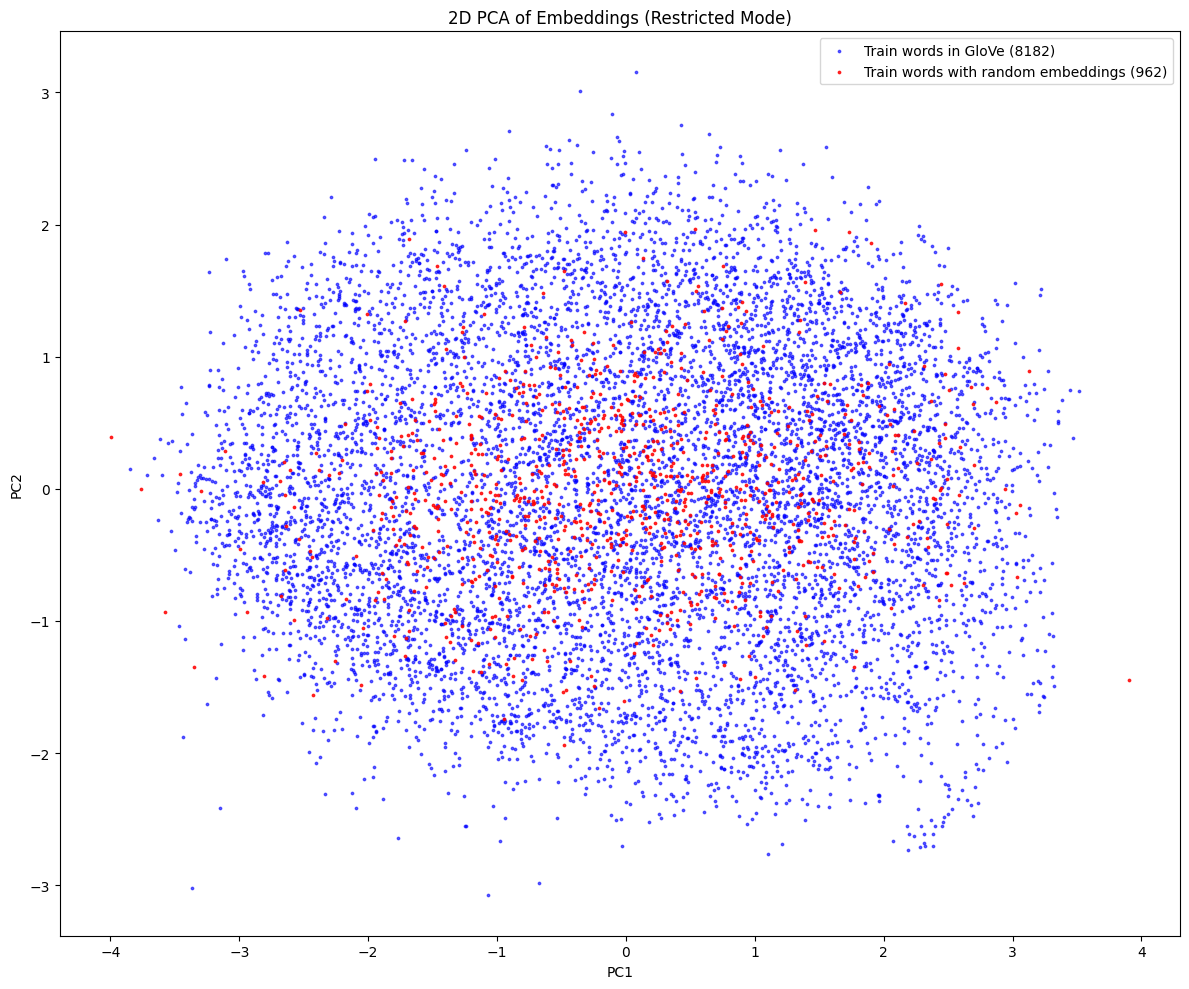

In [13]:
embedding_vocab = set(embedding_model.index_to_key)
train_vocab = set(train_words)

if USE_FULL_PRELOAD_EMB_MODEL:
    # Full-preload mode: visualize all words in tokenizer with category distinctions
    
    # Get all words from tokenizer
    tokenizer_words = set(tokenizer.word_index.keys())
    
    # Categorize based on origin
    cat_train_in_embed = list(train_vocab & embedding_vocab)        # Train words with GloVe embeddings
    cat_embed_only = list((tokenizer_words & embedding_vocab) - train_vocab)  # GloVe words not in train
    cat_train_random = list(train_vocab - embedding_vocab)          # Train words with random embeddings
    
    # Collect embedding vectors for each category
    embed_train_in_embed = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_in_embed])
    embed_embed_only = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_embed_only])
    embed_train_random = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_random])
    
    # Combine all vectors for PCA
    all_embeddings = np.concatenate([embed_train_in_embed, embed_embed_only, embed_train_random], axis=0)
    pca = PCA(n_components=2)
    all_2d = pca.fit_transform(all_embeddings)
    
    # Split projected coordinates by category
    n_train_in_embed = len(embed_train_in_embed)
    n_embed_only = len(embed_embed_only)
    n_train_random = len(embed_train_random)
    
    coords_train_in_embed = all_2d[:n_train_in_embed]
    coords_embed_only = all_2d[n_train_in_embed:n_train_in_embed + n_embed_only]
    coords_train_random = all_2d[n_train_in_embed + n_embed_only:]
    
    # Plot each category
    plt.figure(figsize=(12, 10))
    plt.scatter(coords_train_in_embed[:, 0], coords_train_in_embed[:, 1], s=3, alpha=0.6, color="blue",
                label=f"Train words in GloVe ({len(cat_train_in_embed)})")
    plt.scatter(coords_embed_only[:, 0], coords_embed_only[:, 1], s=3, alpha=0.4, color="green",
                label=f"GloVe words not in train ({len(cat_embed_only)})")
    plt.scatter(coords_train_random[:, 0], coords_train_random[:, 1], s=3, alpha=0.8, color="red",
                label=f"Train words with random embeddings ({len(cat_train_random)})")
    
    plt.title("2D PCA of Embeddings (Full Model Mode)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    # Restricted mode: only train words are in tokenizer
    
    # Get all words from tokenizer (should be only train_vocab)
    tokenizer_words = set(tokenizer.word_index.keys())
    
    # Categorize based on whether they have GloVe embeddings or random ones
    cat_train_in_embed = list(train_vocab & embedding_vocab)    # Train words with GloVe embeddings
    cat_train_random = list(train_vocab - embedding_vocab)      # Train words with random embeddings

    # Collect embedding vectors for each category
    embed_train_in_embed = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_in_embed])
    embed_train_random = np.array([embedding_matrix[tokenizer.word_index[t]] for t in cat_train_random])

    # Combine all vectors for PCA
    all_embeddings = np.concatenate([embed_train_in_embed, embed_train_random], axis=0)
    pca = PCA(n_components=2)
    all_2d = pca.fit_transform(all_embeddings)

    # Split projected coordinates by category
    n_train_in_embed = len(embed_train_in_embed)
    n_train_random = len(embed_train_random)

    coords_train_in_embed = all_2d[:n_train_in_embed]
    coords_train_random = all_2d[n_train_in_embed:]

    # Plot each category
    plt.figure(figsize=(12, 10))
    plt.scatter(coords_train_in_embed[:, 0], coords_train_in_embed[:, 1], s=3, alpha=0.6, color="blue",
                label=f"Train words in GloVe ({len(cat_train_in_embed)})")
    plt.scatter(coords_train_random[:, 0], coords_train_random[:, 1], s=3, alpha=0.8, color="red",
                label=f"Train words with random embeddings ({len(cat_train_random)})")

    plt.title("2D PCA of Embeddings (Restricted Mode)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

# [Task 4 - 1.0 points] Model definition

You are now tasked to define your sexism classifier.




### Instructions

* **Baseline**: implement a Bidirectional LSTM with a Dense layer on top.

* **Stacked**: add an additional Bidirectional LSTM layer to the Baseline model.

**Note**: You are **free** to experiment with hyper-parameters.

In [14]:
NUM_CLASSES = len(label_mapping.keys())
MAX_SEQ_LEN = max([df['cleaned_lemm_tweet'].apply(lambda x: len(x.split())).max() for df in dfs])

# NOTE: la struttura potrebbe essere too much ma visto che con ipcv ci eravamo trovati "bene" a testarla l'ho riproposta
hyperparams_models = {
    "baseline": {
        "model": {
            "lstm_units": 64,
            "dense_units": 64,
            "dropout_rate": 0.2,   
        },
        "train": {}
    },
    "stacked": {
        "model": {
            "lstm_units_1": 64,
            "lstm_units_2": 32,
            "dense_units": 64,
            "dropout_rate_1": 0.3,
            "dropout_rate_2": 0.2,
        },
        "train": {}
    }
}

### Token to embedding mapping

You can follow two approaches for encoding tokens in your classifier.

### Work directly with embeddings

- Compute the embedding of each input token
- Feed the mini-batches of shape ``(batch_size, # tokens, embedding_dim)`` to your model

### Work with Embedding layer

- Encode input tokens to token ids
- Define a Embedding layer as the first layer of your model
- Compute the embedding matrix of all known tokens (i.e., tokens in your vocabulary)
- Initialize the Embedding layer with the computed embedding matrix
- You are **free** to set the Embedding layer trainable or not

In [92]:
# ============================================
# CORRECT SOLUTION: Use functions
# ============================================

def create_baseline_model(seed, tot=False):
    """Factory function that creates a NEW baseline model"""
    embedding_matrix, random_idxs = build_embedding_matrix(
    tokenizer=tokenizer,
    embedding_model=embedding_model,
    seed=seed,
    verbose=False,
    totally_random=tot
)
    return Sequential([
        Input(shape=(MAX_SEQ_LEN,)),
        Embedding(
            input_dim=vocab_size, 
            output_dim=EMBEDDING_DIMENSION,
            weights=[embedding_matrix],
            mask_zero=False,
            name='encoder_embedding'
        ),
        Bidirectional(LSTM(
            units=hyperparams_models["baseline"]["model"]["lstm_units"],
            return_sequences=False
        )),
        #Dropout(hyperparams_models["baseline"]["model"]["dropout_rate"]),
        #Dense(
        #    units=hyperparams_models["baseline"]["model"]["dense_units"],
        #    activation='relu'
        #),
        Dense(units=NUM_CLASSES, activation='softmax')
    ], name="baseline_bidirectional_lstm")

def create_stacked_model(seed, tot=False):
    """Factory function that creates a NEW stacked model"""
    embedding_matrix, random_idxs = build_embedding_matrix(
    tokenizer=tokenizer,
    embedding_model=embedding_model,
    seed=seed,
    verbose=False,
    totally_random=tot
)
    return Sequential([
        Input(shape=(MAX_SEQ_LEN,)),
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIMENSION,
            weights=[embedding_matrix],
            mask_zero=True,
            name='encoder_embedding'
        ),
        Bidirectional(LSTM(
            units=hyperparams_models["stacked"]["model"]["lstm_units_1"],
            return_sequences=True  # NOTE: return sequences for stacking
        )),
        Dropout(hyperparams_models["stacked"]["model"]["dropout_rate_1"]),
        Bidirectional(LSTM(
            units=hyperparams_models["stacked"]["model"]["lstm_units_2"],
            return_sequences=False
        )),
        #Dropout(hyperparams_models["stacked"]["model"]["dropout_rate_2"]),
        #Dense(
        #    units=hyperparams_models["stacked"]["model"]["dense_units"],
        #    activation='relu'
        #),
        Dense(units=NUM_CLASSES, activation='softmax')
    ], name="stacked_bidirectional_lstm")

models = {
    "baseline": create_baseline_model,  # ✅ Function (no parentheses!)
    "stacked": create_stacked_model     # ✅ Function (no parentheses!)
}

# [Task 5 - 1.0 points] Training and Evaluation

You are now tasked to train and evaluate the Baseline and Stacked models.



### Instructions

* Pick **at least** three seeds for robust estimation.
* Train **all** models on the train set.
* Evaluate **all** models on the validation and test sets.
* Compute macro F1-score, precision, and recall metrics on the validation set.
* Report average and standard deviation measures over seeds for each metric.
* Pick the **best** performing model according to the observed validation set performance (use macro F1-score).

## Convert text to sequence

In [16]:
def texts_to_sequences(texts, word_to_idx):
    """Convert text strings to sequences of indices"""
    sequences = []
    for text in texts:
        tokens = text.split()
        indices = [word_to_idx.get(token, word_to_idx.get('<OOV>', 1)) for token in tokens]
        sequences.append(indices)
    return sequences

# Convert train/val/test texts to sequences
X_train_sequences = texts_to_sequences(train_df['cleaned_lemm_tweet'].values, tokenizer.word_index)
X_val_sequences = texts_to_sequences(val_df['cleaned_lemm_tweet'].values, tokenizer.word_index)
X_test_sequences = texts_to_sequences(test_df['cleaned_lemm_tweet'].values, tokenizer.word_index)

## Pad sequences

In [17]:
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_SEQ_LEN, padding='post')

print(f"X_train shape: {X_train_padded.shape}")
print(f"X_val shape: {X_val_padded.shape}")
print(f"X_test shape: {X_test_padded.shape}")

X_train shape: (2873, 63)
X_val shape: (150, 63)
X_test shape: (280, 63)


##  It is necessary to one-hot encode labels

In [18]:
NUM_CLASSES = len(train_df['label'].unique())

y_train_cat = to_categorical(train_df['label'].values, num_classes=NUM_CLASSES)
y_val_cat = to_categorical(val_df['label'].values, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(test_df['label'].values, num_classes=NUM_CLASSES)

print(f"y_train shape: {y_train_cat.shape}")
print(f"Number of classes: {NUM_CLASSES}")

y_train shape: (2873, 4)
Number of classes: 4


## Train the models

In [19]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights automatically
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weight_dict={}

for i in range(len(dict(enumerate(class_weights)))):
    class_weight_dict[i]=dict(enumerate(class_weights))[i]*1

print(class_weight_dict)

{0: 0.3566285998013903, 1: 1.3375232774674115, 2: 5.204710144927536, 3: 3.9035326086956523}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import AdamW
from collections import Counter


# Function for setting all the seeds
def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


# Define function for computing metrics
def compute_metrics(output_info):
    """
    Compute metrics from model outputs
    
    Args:
        output_info: tuple of (labels, logits) or (logits, labels)
    """
    # Handle both orderings
    if len(output_info[0].shape) == 1:  # First element is labels (1D)
        labels, logits = output_info
    else:  # First element is logits (2D)
        logits, labels = output_info
    
    # Convert one-hot to class indices if needed
    if len(labels.shape) > 1:
        labels = np.argmax(labels, axis=-1)
    
    # Get predictions
    preds = np.argmax(logits, axis=-1)
    
    # Calculate metrics
    f1 = f1_score(labels, preds, average="macro")
    accuracy = accuracy_score(labels, preds)

    return {
        "macro_f1": f1,
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy,
        "custom_metric": (f1 + accuracy) / 2
    }

import numpy as np
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

class MetricsCallback(Callback):
    """
    Custom callback to compute sklearn metrics on validation data
    and store them in history
    """
    
    def __init__(self, validation_data):
        """
        Args:
            validation_data: tuple of (X_val, y_val)
        """
        super().__init__()
        self.validation_data = validation_data
        
    def on_epoch_end(self, epoch, logs=None):
        """
        Called at the end of each epoch
        Computes metrics and adds them to logs (which become history)
        """
        logs = logs or {}
        
        # Get validation data
        X_val, y_val = self.validation_data
        
        # Get predictions
        y_pred_probs = self.model.predict(X_val, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=-1)
        
        # Convert one-hot to class indices if needed
        if len(y_val.shape) > 1:
            y_true = np.argmax(y_val, axis=-1)
        else:
            y_true = y_val
        
        # Calculate metrics
        val_f1 = f1_score(y_true, y_pred, average='macro')
        val_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
        val_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
        val_accuracy = accuracy_score(y_true, y_pred)
        
        # Add to logs (these will be saved in history)
        logs['val_f1'] = val_f1
        logs['val_precision'] = val_precision
        logs['val_recall'] = val_recall
        logs['val_accuracy_sklearn'] = val_accuracy  # Different from Keras accuracy
        
        # Print metrics
        print(f"\n  - val_f1: {val_f1:.4f} - val_precision: {val_precision:.4f} - val_recall: {val_recall:.4f}")
        
        return logs
    
def evaluation(models, seeds=[42,90,77], dir='./'):

    
    
    logs = {'baseline':{'val_macro_f1':[], 'val_macro_precision':[], 'val_macro_recall':[], 'val_accuracy':[],
                        'test_macro_f1':[], 'test_macro_precision':[], 'test_macro_recall':[], 'test_accuracy':[]}, 
            'stacked':{'val_macro_f1':[], 'val_macro_precision':[], 'val_macro_recall':[], 'val_accuracy':[],
                        'test_macro_f1':[], 'test_macro_precision':[], 'test_macro_recall':[], 'test_accuracy':[]}}
    
    for val in [True, False]:
        if val is True:
            n='val'
            X_padded=X_val_padded
            y_cat=y_val_cat
        else:
            n='test'
            X_padded=X_test_padded
            y_cat=y_test_cat

        for seed in seeds:
            set_all_seeds(seed)
            for model in models:
                current_model = models[model](seed=seed, tot=False)
                current_model.load_weights(f'{dir}/weights_{model}_seed{seed}.weights.h5')

                # Get predictions
                y_pred_probs = current_model.predict(X_padded, verbose=0)
                y_pred = np.argmax(y_pred_probs, axis=-1)

                # Convert one-hot to class indices if needed
                if len(y_cat.shape) > 1:
                    y_true = np.argmax(y_cat, axis=-1)
                else:
                    y_true = y_cat

                # Calculate metrics
                f1 = f1_score(y_true, y_pred, average='macro')
                precision=precision_score(y_true, y_pred, average='macro')
                recall=recall_score(y_true, y_pred, average='macro')
                accuracy=accuracy_score(y_true, y_pred)

                # Add to logs (these will be saved in history)
                logs[model][f'{n}_macro_f1'].append(f1)
                logs[model][f'{n}_macro_precision'].append(precision)
                logs[model][f'{n}_macro_recall'].append(recall)
                logs[model][f'{n}_accuracy'].append(accuracy)
    
    logs['baseline']['seed']=logs['stacked']['seed']=seeds

    return pd.DataFrame(logs['baseline']), pd.DataFrame(logs['stacked'])

def train_and_eval_seeds(models, X_train_padded, y_train_cat, X_val_padded, y_val_cat, class_weight_dict=None,
                         seeds=[42, 90, 77], lr=1e-4, wd=0.01, patience=3, 
                         epochs=40, batch_size=8, save_weights=True, dir='./', load_weights=True, tot=False):
    """Train and evaluate models with multiple random seeds"""
    
    histories = {}
    results = {}
    f1_scores = {model_name: [] for model_name in models.keys()}

    for seed in seeds:
        print(f"\n{'='*80}")
        print(f"SEED: {seed}")
        print(f"{'='*80}")
        
        set_all_seeds(seed)
        
        histories[seed] = {}
        results[seed] = {}

        for model_name in models.keys():
            # Create new model
            current_model = models[model_name](seed=seed, tot=tot)

            if load_weights is True:
                print('loading weights for all the models.')
                current_model.load_weights(f'{dir}/weights_{model_name}_seed{seed}.weights.h5')
            else:
                print(f"\n{'='*60}")
                print(f"Training: {model_name} (seed={seed})")
                print(f"{'='*60}")


                # Compile
                current_model.compile(
                optimizer=AdamW(learning_rate=lr, weight_decay=wd),
                loss='categorical_crossentropy',
                metrics=['accuracy']
             )
    
                # Print summary only once
                if seed == seeds[0]:
                    print("\nModel Architecture:")
                    current_model.summary()
                
                # Custom metrics callback
                metrics_callback = MetricsCallback(
                    validation_data=(X_val_padded, y_val_cat)
                )
                
                early_stopping = EarlyStopping(
                    monitor='val_f1',
                    patience=patience,
                    mode='max',
                    restore_best_weights=True,
                    verbose=1
                )
                
                # Combine callbacks
                callbacks = [metrics_callback, early_stopping]
                
                if class_weight_dict is not None:
                    history = current_model.fit(
                        x=X_train_padded,
                        y=y_train_cat,
                        validation_data=(X_val_padded, y_val_cat),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=callbacks,
                        verbose=1,
                        class_weight=class_weight_dict
                    )
                else:
                    history = current_model.fit(
                        x=X_train_padded,
                        y=y_train_cat,
                        validation_data=(X_val_padded, y_val_cat),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=callbacks,
                        verbose=1,
                        class_weight=class_weight_dict
                    )
                
                print(f"\n{'='*60}")
                print("Training History Metrics Available:")
                print(f"{'='*60}")
                print(f"Keys in history: {history.history.keys()}")
                # Will show: dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 
                #                       'val_f1', 'val_precision', 'val_recall'])
                
                # Save weights
                if save_weights:
                    weight_path = f'{dir}/weights_{model_name}_seed{seed}.weights.h5'
                    current_model.save_weights(weight_path)
    
                best_epoch_idx = np.argmax(history.history['val_f1'])
    
                # Get final metrics
                final_metrics = {
                    'val_accuracy': history.history['val_accuracy'][best_epoch_idx],
                    'val_loss': history.history['val_loss'][best_epoch_idx],
                    'val_f1': history.history['val_f1'][best_epoch_idx],
                    'val_precision': history.history['val_precision'][best_epoch_idx],
                    'val_recall': history.history['val_recall'][best_epoch_idx]
                }
    
                # Store results
                histories[seed][model_name] = history
                results[seed][model_name] = final_metrics
                f1_scores[model_name].append(final_metrics['val_f1'])
                
                print(f"\nFinal Results for {model_name} (seed={seed}):")
                print(f"  Val Accuracy: {final_metrics['val_accuracy']:.4f}")
                print(f"  Val F1: {final_metrics['val_f1']:.4f}")
                print(f"  Val Precision: {final_metrics['val_precision']:.4f}")
                print(f"  Val Recall: {final_metrics['val_recall']:.4f}")
                
                # Clean up
                tf.keras.backend.clear_session()

    if load_weights is True:
        print('='*80)
        evaluation(models, X_val_padded, y_val_cat, seeds, dir)
        return

                # Summary
    print(f"\n{'='*80}")
    print("SUMMARY ACROSS SEEDS")
    print(f"{'='*80}")
    
    for model_name, scores in f1_scores.items():
        mean_f1 = np.mean(scores)
        std_f1 = np.std(scores)
        print(f"\n{model_name}:")
        print(f"  F1 scores: {[f'{s:.4f}' for s in scores]}")
        print(f"  Mean F1: {mean_f1:.4f} ± {std_f1:.4f}")
    
    return histories, results, f1_scores

# Add this RIGHT BEFORE training
def clear_all_memory():
    """Aggressive memory cleanup"""
    tf.keras.backend.clear_session()
    gc.collect()
    
    # If on GPU
    try:
        from numba import cuda
        cuda.select_device(0)
        cuda.close()
    except:
        pass

def mean_std(df_out: pd.DataFrame):
    metrics_to_agg = [
        "val_macro_f1", "test_macro_f1", "val_macro_precision", "test_macro_precision",
        "val_macro_recall", "test_macro_recall",
           "val_accuracy","test_accuracy"
    ]
    agg = df_out[metrics_to_agg].agg(["mean", "std"])

    # Select best run according to validation macro-F1
    best_idx = df_out["val_macro_f1"].idxmax()
    best_run = df_out.loc[best_idx]
    return agg, best_run


def plot_summary_metrics(df_out: pd.DataFrame, agg: pd.DataFrame, best_run: pd.Series = None,
                         figsize=(12, 10), save_path: str = None):
    """
    3-row figure:
      row1: grouped bars for validation metrics (one bar per seed per metric)
      row2: grouped bars for test metrics
      row3: mean ± std for each metric across seeds (no boxplots)
    """
    val_metrics = ["val_macro_f1", "val_macro_precision", "val_macro_recall", "val_accuracy"]
    test_metrics = ["test_macro_f1", "test_macro_precision", "test_macro_recall", "test_accuracy"]
    all_metrics = val_metrics + test_metrics

    # Input checks
    missing = [c for c in all_metrics if c not in df_out.columns]
    if missing:
        raise ValueError(f"df_out missing columns: {missing}")

    seeds = df_out["seed"].tolist()
    n_seeds = len(seeds)
    cmap = plt.get_cmap("tab10")

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=figsize)
    plt.subplots_adjust(hspace=0.5)

    # Row 1: Validation grouped bars
    ax = axes[0]
    x = np.arange(len(val_metrics))
    total_width = 0.8
    bar_width = total_width / max(1, n_seeds)
    offsets = np.linspace(-total_width/2 + bar_width/2, total_width/2 - bar_width/2, n_seeds)

    for i, (seed, offset) in enumerate(zip(seeds, offsets)):
        row = df_out[df_out["seed"] == seed].iloc[0]
        vals = [row[m] for m in val_metrics]
        edge = 'black' if (best_run is not None and seed == int(best_run["seed"])) else None
        lw = 1.6 if (best_run is not None and seed == int(best_run["seed"])) else 0.6
        ax.bar(x + offset, vals, width=bar_width, alpha=0.85, label=f"seed {seed}", color=cmap(i % 10),
               edgecolor=edge, linewidth=lw)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("val_", "") for m in val_metrics], rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("score")
    ax.set_title("Validation metrics by seed")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(ncol=min(4, n_seeds), fontsize="small", loc="upper center", bbox_to_anchor=(0.5, -0.15))

    # if best_run is not None:
    #     for j, m in enumerate(val_metrics):
    #         best_val = float(best_run[m])
    #         ax.scatter(j, best_val + 0.03, marker="*", s=120, c="black", zorder=6)

    # Row 2: Test grouped bars
    ax = axes[1]
    x = np.arange(len(test_metrics))
    for i, (seed, offset) in enumerate(zip(seeds, offsets)):
        row = df_out[df_out["seed"] == seed].iloc[0]
        vals = [row[m] for m in test_metrics]
        edge = 'black' if (best_run is not None and seed == int(best_run["seed"])) else None
        lw = 1.6 if (best_run is not None and seed == int(best_run["seed"])) else 0.6
        ax.bar(x + offset, vals, width=bar_width, alpha=0.85, label=f"seed {seed}", color=cmap(i % 10),
               edgecolor=edge, linewidth=lw)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("test_", "") for m in test_metrics], rotation=0)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("score")
    ax.set_title("Test metrics by seed")
    ax.grid(axis="y", alpha=0.3)

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    # if best_run is not None:
    #     for j, m in enumerate(test_metrics):
    #         best_val = float(best_run[m])
    #         ax.scatter(j, best_val + 0.03, marker="*", s=120, c="black", zorder=6)
    #         print("j" , j, "m", m, "best_val", best_val)

    # Row 3: Mean ± Std only (no boxplots)
    ax = axes[2]
    all_metrics = ["val_macro_f1","test_macro_f1", "val_macro_precision","test_macro_precision", 
                   "val_macro_recall","test_macro_recall", "val_accuracy","test_accuracy"]
    
    # get means and stds from agg if available; otherwise compute from df_out
    if ("mean" in agg.index) and ("std" in agg.index):
        means = agg.loc["mean", all_metrics].values
        stds = agg.loc["std", all_metrics].values
    else:
        means = np.array([df_out[m].mean() for m in all_metrics])
        stds = np.array([df_out[m].std(ddof=1) for m in all_metrics])

    x = np.arange(len(all_metrics))
    colors = [cmap(i % 10) for i in range(len(all_metrics))]
    bars = ax.bar(x, means, yerr=stds, capsize=6, tick_label=[m for m in all_metrics],
                  color=colors, alpha=0.85, edgecolor='k')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("mean ± std")
    ax.set_title("Mean ± Std across seeds (validation + test metrics)")
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # optional: annotate mean values above bars
    for xi, (mu, sigma) in enumerate(zip(means, stds)):
        ax.text(xi, mu + sigma + 0.02, f"{mu:.3f}±{sigma:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()



In [ ]:
import gc
import tensorflow as tf

load_weights=True

# Run this
clear_all_memory()

# Use the function
if load_weights is True:
    train_and_eval_seeds(models, X_train_padded,
                        y_train_cat, X_val_padded,
                        y_val_cat, class_weight_dict=class_weight_dict, 
                        dir='./weights/base', load_weights=load_weights)
else:
    histories, results, f1_voc = train_and_eval_seeds(models, X_train_padded, y_train_cat, X_val_padded,
                                                   y_val_cat, class_weight_dict=class_weight_dict, dir='./weights/base', load_weights=load_weights)



SEED: 42
loading weights for all the models.
loading weights for all the models.

SEED: 90
loading weights for all the models.
loading weights for all the models.

SEED: 77
loading weights for all the models.
loading weights for all the models.
baseline
[0.4626692456479691, 0.46618015016838166, 0.36438369574198276]
  Mean F1: 0.4311 ± 0.0472
stacked
[0.4585971205816234, 0.4511823132468624, 0.41837140420431496]
  Mean F1: 0.4427 ± 0.0175


## Plot and report the results


Plotting seed: 42
  Model: baseline
  Model: stacked

Plotting seed: 90
  Model: baseline
  Model: stacked

Plotting seed: 77
  Model: baseline
  Model: stacked


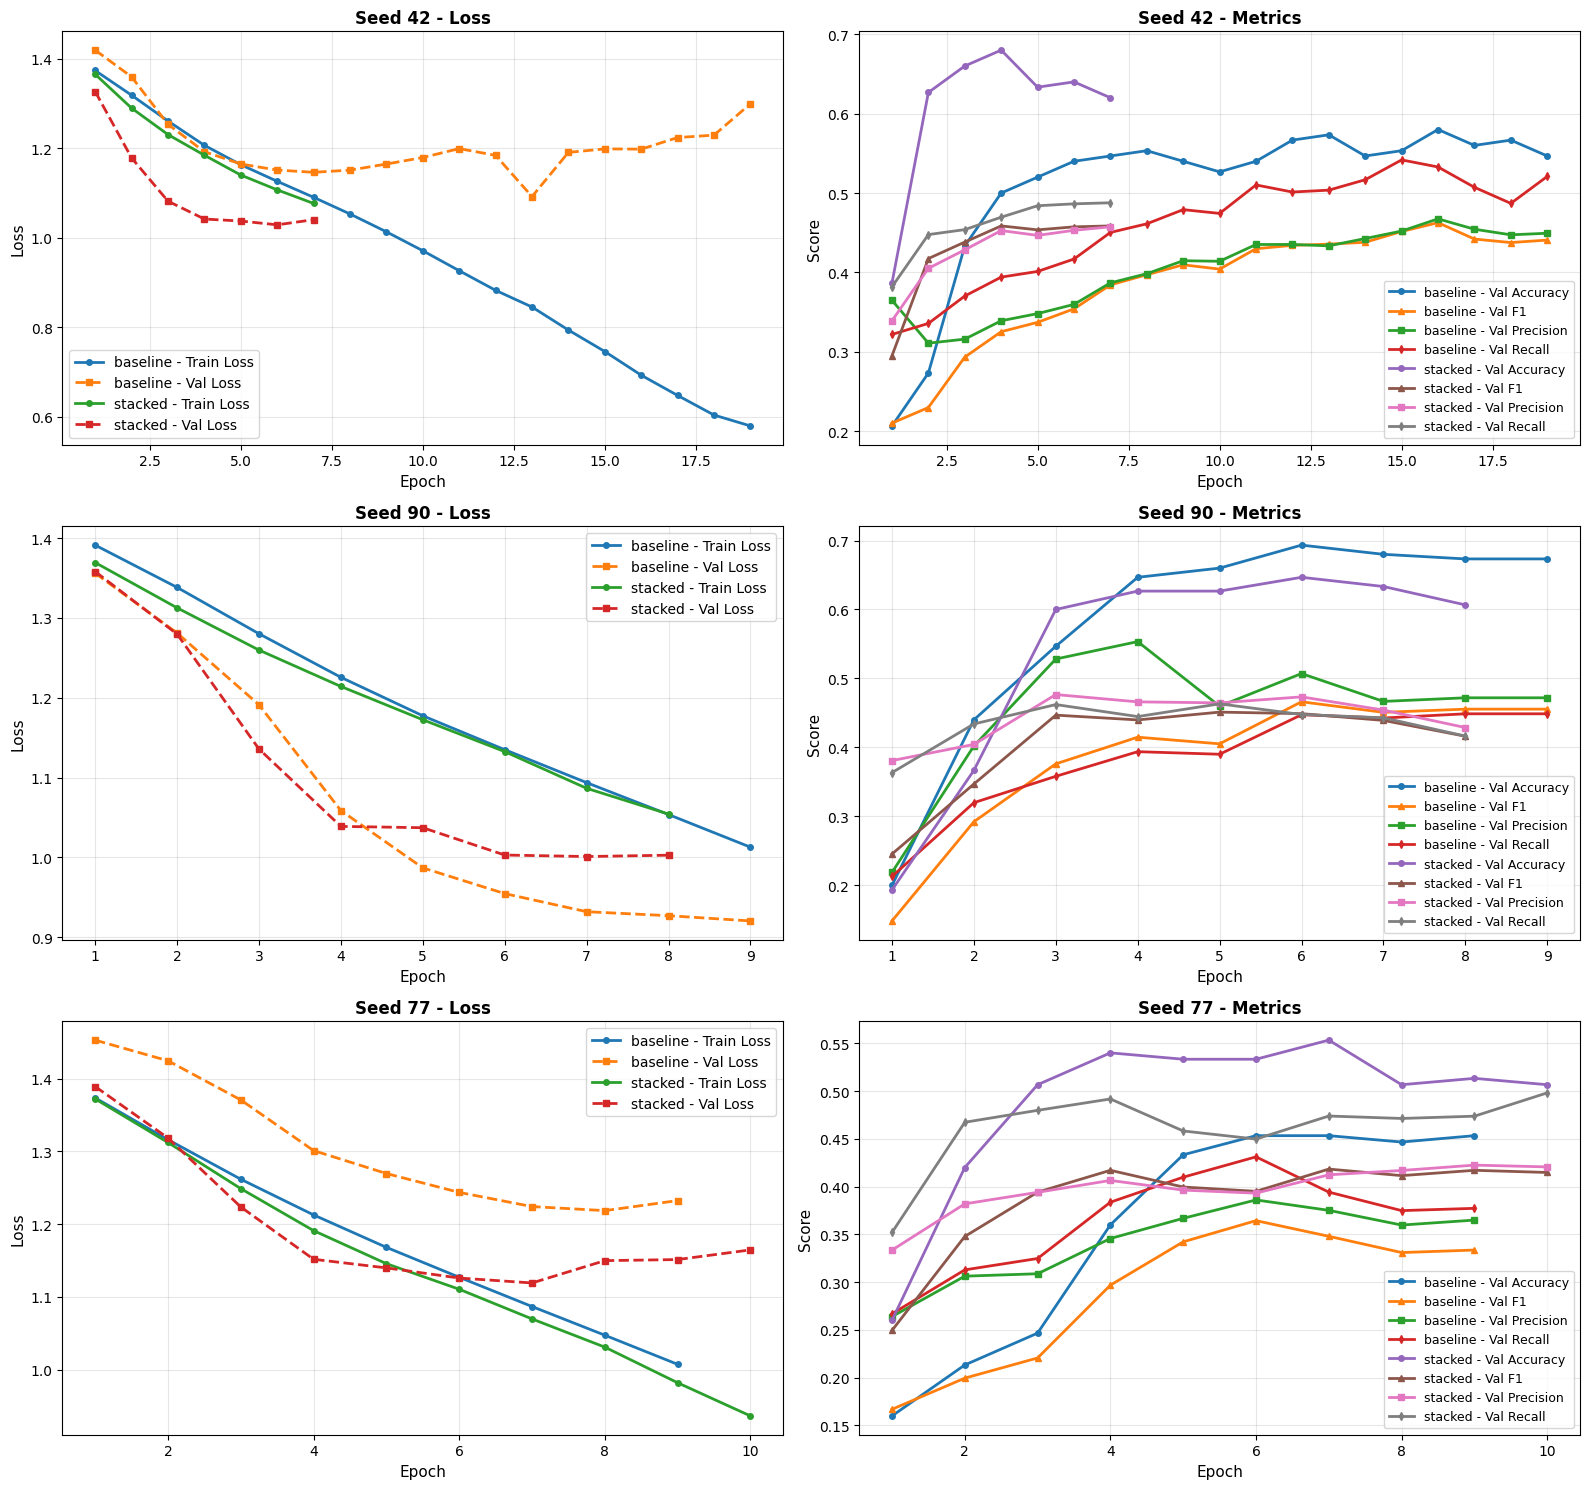

In [39]:
def plot_training_history(histories):
    """Plot training and validation metrics for all seeds and models"""
    
    seeds = list(histories.keys())
    n_seeds = len(seeds)
    
    fig, axes = plt.subplots(n_seeds, 2, figsize=(16, 5 * n_seeds))
    
    # Handle single seed case
    if n_seeds == 1:
        axes = axes.reshape(1, -1)
    
    for i, seed in enumerate(seeds):
        print(f"\nPlotting seed: {seed}")
        
        for model_name in histories[seed].keys():
            print(f"  Model: {model_name}")
            
            # Get history as DataFrame
            history_df = pd.DataFrame(histories[seed][model_name].history)
            epochs = range(1, len(history_df) + 1)
            
            # Plot 1: Loss
            axes[i, 0].plot(epochs, history_df['loss'], 
                          label=f'{model_name} - Train Loss', 
                          linewidth=2, marker='o', markersize=4)
            axes[i, 0].plot(epochs, history_df['val_loss'], 
                          label=f'{model_name} - Val Loss', 
                          linewidth=2, marker='s', markersize=4, linestyle='--')
            
            axes[i, 0].set_xlabel('Epoch', fontsize=11)
            axes[i, 0].set_ylabel('Loss', fontsize=11)
            axes[i, 0].set_title(f'Seed {seed} - Loss', fontsize=12, fontweight='bold')
            axes[i, 0].legend(loc='best')
            axes[i, 0].grid(True, alpha=0.3)
            
            # Plot 2: Metrics (Accuracy, F1, Precision, Recall)
            axes[i, 1].plot(epochs, history_df['val_accuracy'], 
                          label=f'{model_name} - Val Accuracy', 
                          linewidth=2, marker='o', markersize=4)
            
            # Check if custom metrics exist
            if 'val_f1' in history_df.columns:
                axes[i, 1].plot(epochs, history_df['val_f1'], 
                              label=f'{model_name} - Val F1', 
                              linewidth=2, marker='^', markersize=4)
            
            if 'val_precision' in history_df.columns:
                axes[i, 1].plot(epochs, history_df['val_precision'], 
                              label=f'{model_name} - Val Precision', 
                              linewidth=2, marker='s', markersize=4)
            
            if 'val_recall' in history_df.columns:
                axes[i, 1].plot(epochs, history_df['val_recall'], 
                              label=f'{model_name} - Val Recall', 
                              linewidth=2, marker='d', markersize=4)
            
            axes[i, 1].set_xlabel('Epoch', fontsize=11)
            axes[i, 1].set_ylabel('Score', fontsize=11)
            axes[i, 1].set_title(f'Seed {seed} - Metrics', fontsize=12, fontweight='bold')
            axes[i, 1].legend(loc='best', fontsize=9)
            axes[i, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Call once for all histories
plot_training_history(histories)

,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.452086,0.482300,0.518970,0.553333,0.347885,0.375378,0.391404,0.467857,42
1,0.304428,0.373810,0.309084,0.686667,0.340774,0.395866,0.340358,0.621429,90
2,0.359295,0.382028,0.427433,0.466667,0.321158,0.358086,0.372716,0.396429,77


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.371936,0.336606,0.412713,0.376443,0.418496,0.368159,0.568889,0.495238
std,0.074636,0.013842,0.060405,0.018912,0.105228,0.025826,0.110822,0.114972


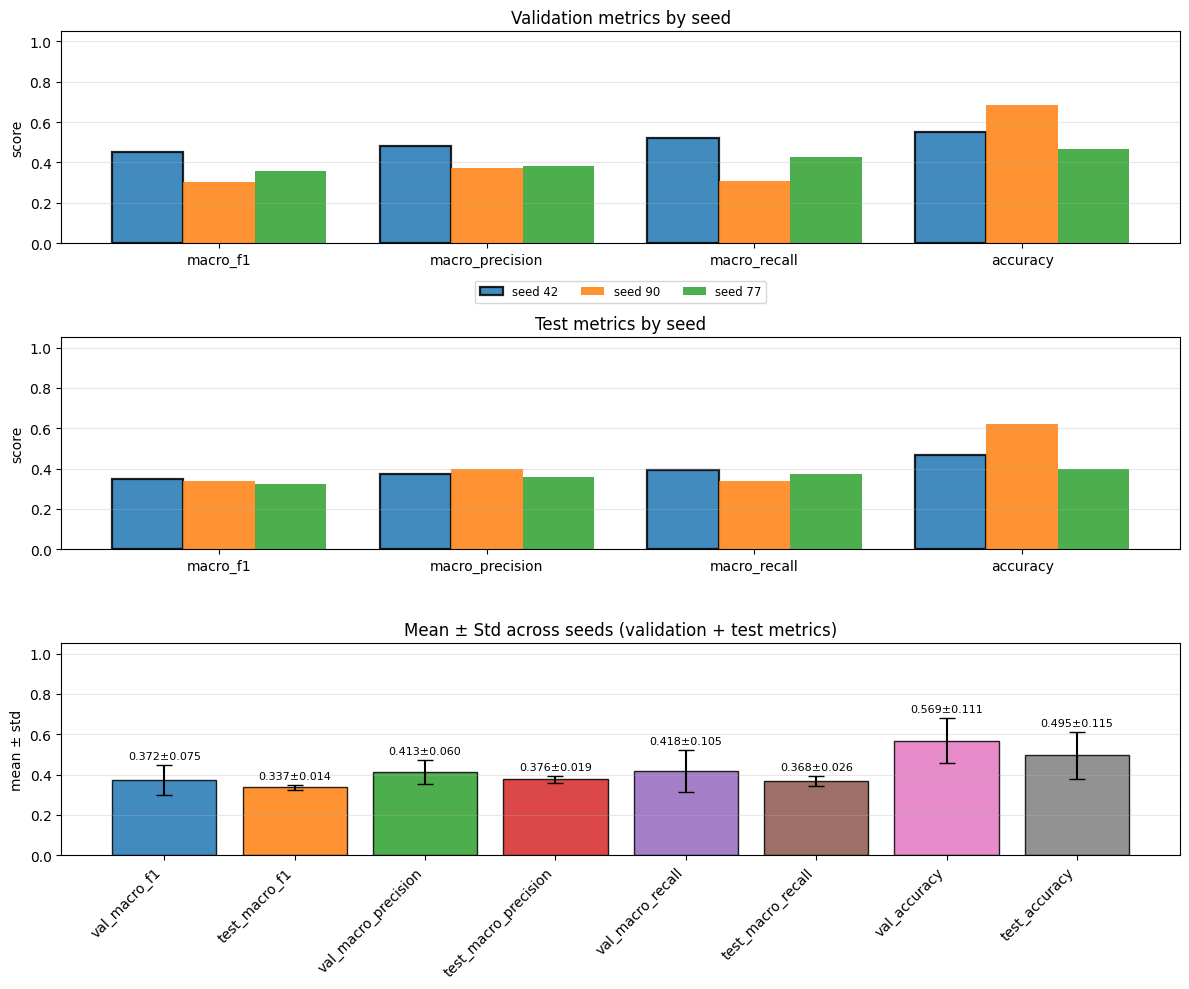

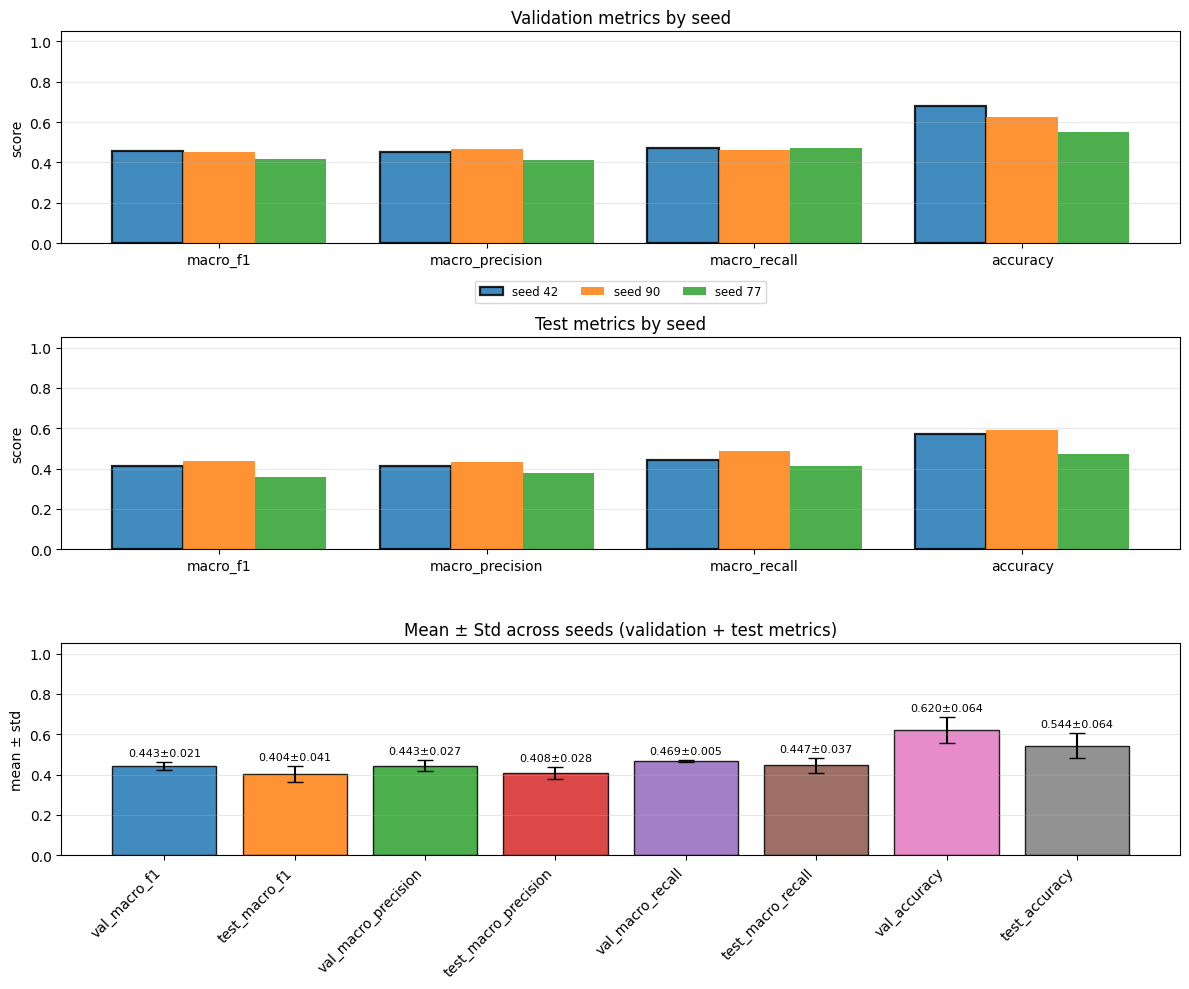

In [ ]:
logs_base, logs_stacked = evaluation(models, dir='./weights/base')
agg_base, best_run_base=mean_std(logs_base)
display(logs_base)
display(agg_base)
plot_summary_metrics(logs_base, agg_base, best_run_base)
agg_stacked, best_run_stacked=mean_std(logs_stacked)
display(logs_stacked)
display(agg_stacked)
plot_summary_metrics(logs_stacked, agg_stacked, best_run_stacked)

# [Task 6 - 1.0 points] Transformers

In this section, you will use a transformer model specifically trained for hate speech detection, namely [Twitter-roBERTa-base for Hate Speech Detection](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate).




### Relevant Material
- Tutorial 3

### Instructions
- **Load the Tokenizer and Model**

- **Preprocess the Dataset**:
   You will need to preprocess your dataset to prepare it for input into the model. Tokenize your text data using the appropriate tokenizer and ensure it is formatted correctly.

- **Train the Model**:
   Use the `Trainer` to train the model on your training data.

- **Evaluate the Model on the Test Set** using the same metrics used for LSTM-based models.

In [ ]:
TASK='hate'
MODEL_CARD = f"twitter-roberta-base-{TASK}"
NUM_LABLES = 4
output_dir = "./pt_checkpoints"
seeds = [42, 26, 6]

# Dataset preparation

# TODO: tokenizer = AutoTokenizer.from_pretrained(MODEL_CARD)
tokenizer = AutoTokenizer.from_pretrained(MODEL_CARD, use_fast=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def preprocess_text_precleaned(tweets):
    return tokenizer(tweets['cleaned_only_tweet'], truncation=True, padding=True , return_tensors="pt")

train_data = Dataset.from_pandas(train_df[["cleaned_only_tweet","label"]])
test_data = Dataset.from_pandas(test_df[["cleaned_only_tweet","label"]])
val_data = Dataset.from_pandas(val_df[["cleaned_only_tweet","label"]])
train_data = train_data.map(preprocess_text_precleaned, batched=True)
test_data = test_data.map(preprocess_text_precleaned, batched=True)
val_data = val_data.map(preprocess_text_precleaned, batched=True)

In [ ]:
# check the datasets
if DEBUG:
    print(train_data)
    print(test_data)
    print(val_data)
    print("Encoding of labels:")
    print(" \"-\":0, \"DIRECT\":1, \"JUDGEMENTAL\":2, \"REPORTED\":3")
    print(set(train_data['label']))

    original_text = train_data['cleaned_only_tweet'][26]
    decoded_text = tokenizer.decode(train_data['input_ids'][26])
    print("Original vs Decoded example:")
    print(original_text[:150])
    print(decoded_text[:150])


In [ ]:
def compute_metrics(output_info):
    logits, labels = output_info
    preds = np.argmax(logits, axis=-1)
    f1 = f1_score(labels, preds, average="macro")
    accuracy = accuracy_score(labels, preds)

    return {
        "macro_f1": f1,
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy,
        "custom_metric": (f1 + accuracy) / 2
    }

def count_trainable_parameters(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    return trainable, total


def train_evaluate_model(
    seeds: list[int],
    hyperparameters: dict,
    output_dir: str = "./pt_checkpoints",
    fine_tune_partially: bool = False,
    DEBUG: bool = False,
    plot: bool = True,
    best_subdir_name: str = "best_model"  # folder name inside each run folder where best model is saved
) -> tuple[list[dict], dict, dict]:
    """
    Returns:
      - results: list[dict] with per-seed metrics (same as before)
      - logs: dict of raw trainer.log_history if DEBUG True per seed
      - best_model_dirs: dict mapping seed -> path where the seed's best model is saved
    """
    results = []
    logs = {}
    best_model_dirs = {}

    for seed in seeds:
        print(f"\n=== RUN seed={seed} ===")
        # deterministic seeds 
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        # HF helper (sets python/numpy/torch seeds)
        set_seed(seed)

        # HF helper (sets python/numpy/torch seeds)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # unique output folder per seed so things don't overwrite
        run_output_dir = os.path.join(output_dir, f"seed_{seed}")
        os.makedirs(run_output_dir, exist_ok=True)

        # Model loading
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_CARD,
            num_labels=NUM_LABELS,
            from_tf=False,
            ignore_mismatched_sizes=True,
            id2label=reverse_mapping,
            label2id=label_mapping
        )

        if plot:
            if seed == seeds[0]:
                print(model)
                trainable, total = count_trainable_parameters(model)
                print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

        if fine_tune_partially:
            print("Freezing encoder parameters, fine-tuning classification head only.")
            for param in model.roberta.parameters():
                param.requires_grad = False
            for name, param in model.named_parameters():
                if "classifier" in name or "pooler" in name or "dense" in name:
                    param.requires_grad = True
            trainable, total = count_trainable_parameters(model)
            print(f"Trainable params after freezing encoder: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

        # Training
        training_args = TrainingArguments(
            output_dir=run_output_dir,             
            learning_rate=hyperparameters["learning_rate"],                   
            per_device_train_batch_size=hyperparameters["batch_size"],     # defines distributed training
            per_device_eval_batch_size=hyperparameters["batch_size"],
            num_train_epochs=hyperparameters["epochs"],
            weight_decay=hyperparameters["weight_decay"],
            eval_strategy="epoch",             # when to report evaluation metrics/losses
            save_strategy="epoch",             # when to save checkpoint
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="custom_metric",   # ensure best model by macro F1
            greater_is_better=True,
            report_to='none',                   # disabling wandb 
            seed=seed
        )
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_data,
            eval_dataset=val_data,
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

        trainer.train()

        # gather logs and optional debug storage
        logs_hist = trainer.state.log_history
        df_logs = pd.DataFrame(logs_hist)
        if DEBUG:
            logs[seed] = logs_hist
        if plot:
            plot_metrics_over_epochs(df_logs)  # your plotting helper

        # best info
        best_metric = trainer.state.best_metric
        best_epoch = None
        df_eval = df_logs[df_logs["eval_custom_metric"].notna()].copy()
        if not df_eval.empty:
            best_row = df_eval.loc[df_eval["eval_custom_metric"].idxmax()]
            if pd.notna(best_row.get("epoch", np.nan)):
                best_epoch = float(best_row["epoch"])

        # Evaluate on validation and test
        val_res = trainer.evaluate(eval_dataset=val_data)
        test_res = trainer.evaluate(eval_dataset=test_data)

        record = {
            "seed": seed,
            "val_macro_f1": val_res.get("eval_macro_f1"),
            "val_macro_precision": val_res.get("eval_macro_precision"),
            "val_macro_recall": val_res.get("eval_macro_recall"),
            "val_accuracy": val_res.get("eval_accuracy"),
            "test_macro_f1": test_res.get("eval_macro_f1"),
            "test_macro_precision": test_res.get("eval_macro_precision"),
            "test_macro_recall": test_res.get("eval_macro_recall"),
            "test_accuracy": test_res.get("eval_accuracy"),
            "best_epoch": best_epoch,
            "best_metric": best_metric,
        }
        results.append(record)
        
        if best_subdir_name is not None:
            # Save best model into a dedicated subfolder so it's easy to reload later
            best_dir = os.path.join(run_output_dir, best_subdir_name)
            os.makedirs(best_dir, exist_ok=True)

            # Trainer.save_model will save the model and config into best_dir
            trainer.save_model(best_dir)

            best_model_dirs[seed] = best_dir

        # clean up GPU memory
        del trainer
        del model
        torch.cuda.empty_cache()
        gc.collect()

    return results, logs, best_model_dirs

# Compute mean and std (for validation and test metrics)

def mean_std(df_out: pd.DataFrame):
    metrics_to_agg = [
        "val_macro_f1", "val_macro_precision", "val_macro_recall", "val_accuracy",
        "test_macro_f1", "test_macro_precision", "test_macro_recall", "test_accuracy"
    ]
    agg = df_out[metrics_to_agg].agg(["mean", "std"])

    # Select best run according to validation macro-F1
    best_idx = df_out["val_macro_f1"].idxmax()
    best_run = df_out.loc[best_idx]
    return agg, best_run

def plot_metrics_over_epochs(df_logs: pd.DataFrame):
    """
    Plots:
      - Validation (and training if available) macro-F1 vs precision vs recall across epochs.
      - Loss vs Accuracy for validation and training (training accuracy may be absent).
    df_logs : DataFrame produced from `trainer.state.log_history`.
    """
    # make a safe copy
    df = df_logs.copy()

    # Ensure epoch column exists for grouping; some entries may have fractional epochs or step-level logs
    # We'll group by epoch and take the last available metric for that epoch (more representative).
    df['epoch'] = df.get('epoch', None)

    # Helper to extract series: returns dict epoch -> value
    def epoch_series(key):
        if key in df.columns:
            tmp = df[df[key].notna()].copy()
            if 'epoch' in tmp.columns:
                # take last value per epoch
                return tmp.groupby('epoch')[key].last().sort_index()
            else:
                # no epoch recorded (rare); return the whole series
                return tmp[key]
        return None

    # Validation metrics (expect eval_* keys)
    eval_f1 = epoch_series('eval_macro_f1')
    eval_prec = epoch_series('eval_macro_precision')
    eval_rec = epoch_series('eval_macro_recall')
    eval_loss = epoch_series('eval_loss')
    eval_acc = epoch_series('eval_accuracy')

    # Training metrics: HF usually logs 'loss' for training steps; some setups also log train_* metrics
    # We'll attempt to compute a train-loss-per-epoch by taking the last training 'loss' entry per epoch.
    train_loss = None
    if 'loss' in df.columns:
        tmp = df[df['loss'].notna()].copy()
        if 'epoch' in tmp.columns:
            train_loss = tmp.groupby('epoch')['loss'].last().sort_index()
        else:
            train_loss = tmp['loss']

    train_f1 = epoch_series('train_macro_f1')      # optional
    train_prec = epoch_series('train_macro_precision')
    train_rec = epoch_series('train_macro_recall')
    train_acc = epoch_series('train_accuracy')

    # Plot 1: F1 / Precision / Recall
    plt.figure(figsize=(10, 5))
    plotted_any = False

    if eval_f1 is not None:
        plt.plot(eval_f1.index, eval_f1.values, marker='o', label='val F1')
        plotted_any = True
    if eval_prec is not None:
        plt.plot(eval_prec.index, eval_prec.values, marker='o', label='val Precision')
        plotted_any = True
    if eval_rec is not None:
        plt.plot(eval_rec.index, eval_rec.values, marker='o', label='val Recall')
        plotted_any = True

    # overlay training metrics if present
    if train_f1 is not None:
        plt.plot(train_f1.index, train_f1.values, linestyle='--', marker='x', label='train F1')
    if train_prec is not None:
        plt.plot(train_prec.index, train_prec.values, linestyle='--', marker='x', label='train Precision')
    if train_rec is not None:
        plt.plot(train_rec.index, train_rec.values, linestyle='--', marker='x', label='train Recall')

    if not plotted_any:
        # nothing useful to show
        plt.text(0.5, 0.5, "No F1 / precision / recall metrics logged", ha='center', va='center')
    else:
        plt.xlabel('epoch')
        plt.ylabel('score')
        plt.title('F1 / Precision / Recall by epoch')
        plt.grid(True)
        plt.legend()
    plt.tight_layout()

    # Plot 2: Loss vs Accuracy
    plt.figure(figsize=(10, 5))
    any_plot = False

    # prefer plotting train_loss (if available) and eval_loss
    if train_loss is not None:
        plt.plot(train_loss.index, train_loss.values, linestyle='-', marker='.', label='train loss', color='orange')
        any_plot = True
    if eval_loss is not None:
        plt.plot(eval_loss.index, eval_loss.values, linestyle='-', marker='.', label='val loss', color='red')
        any_plot = True

    # create twin axis for accuracy (same x)
    if eval_acc is not None or train_acc is not None:
        ax1 = plt.gca()
        ax2 = ax1.twinx()
        if eval_acc is not None:
            ax2.plot(eval_acc.index, eval_acc.values, linestyle='--', marker='s', label='val accuracy', color='blue')
            any_plot = True
        if train_acc is not None:
            ax2.plot(train_acc.index, train_acc.values, linestyle='--', marker='v', label='train accuracy', color='green')
            any_plot = True
        ax1.set_ylabel('loss', color='red')
        ax2.set_ylabel('accuracy', color='blue')
        # combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    else:
        if any_plot:
            plt.legend(loc='best')

    if not any_plot:
        plt.text(0.5, 0.5, "No loss/accuracy metrics logged", ha='center', va='center')
    else:
        plt.xlabel('epoch')
        plt.title('Loss (train/val) and Accuracy')
        plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# Hyperparameters
hyper = {
    "batch_size": 8,
    "epochs": 5,
    "learning_rate": 3e-5,
    "weight_decay": 0.01
}

results, logs, best_model_dirs = train_evaluate_model(seeds, hyper, output_dir, fine_tune_partially = False, DEBUG=True)
df_out = pd.DataFrame(results)
df_out = df_out.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)

In [ ]:
display(df_out.filter(regex='seed|best_epoch|val').sort_values("val_macro_f1", ascending=False))
display(df_out.sort_values("val_macro_f1", ascending=False).filter(regex='seed|best_epoch|test'))
agg, best_run = mean_std(df_out)
display(agg)
best_seed = int(best_run.to_dict()["seed"])
print("Best run seed =", best_seed)
# Reload a saved best model for seed 42:
best_dir_for_seed = best_model_dirs[best_seed]
model_seed = AutoModelForSequenceClassification.from_pretrained(best_dir_for_seed)
tokenizer = AutoTokenizer.from_pretrained(best_dir_for_seed)
model_seed.to('cuda' if torch.cuda.is_available() else 'cpu')
training_args = TrainingArguments(report_to='none')
trainer = Trainer(
    model=model_seed,
    args=training_args,
    eval_dataset=test_data,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
metrics = trainer.evaluate()
display(pd.DataFrame([metrics]))

### Also to verify that starting from the cleaned dataset is better respect to starting with the "vanilla" one, and basing all to the roberta tokenizer. I runned thi exp.

In [ ]:
def preprocess_text_vanilla(tweets):
    return tokenizer(tweets['tweet'], truncation=True, padding=True , return_tensors="pt")

train_data = Dataset.from_pandas(train_df[["tweet","label"]])
test_data = Dataset.from_pandas(test_df[["tweet","label"]])
val_data = Dataset.from_pandas(val_df[["tweet","label"]])
train_data = train_data.map(preprocess_text_vanilla, batched=True)
test_data = test_data.map(preprocess_text_vanilla, batched=True)
val_data = val_data.map(preprocess_text_vanilla, batched=True)

In [ ]:
results, logs, best_model_dirs = train_evaluate_model(seeds, hyper, output_dir, fine_tune_partially = False, DEBUG=True, best_subdir_name=None, plot=False)
df_out = pd.DataFrame(results)
df_out = df_out.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)

In [ ]:
display(df_out.filter(regex='seed|best_epoch|val').sort_values("val_macro_f1", ascending=False))
display(df_out.sort_values("val_macro_f1", ascending=False).filter(regex='seed|best_epoch|test'))
agg, best_run = mean_std(df_out)
display(agg)
best_seed = int(best_run.to_dict()["seed"])
print("Best run seed =", best_seed)

# [Task 7 - 0.5 points] Error Analysis

After evaluating the model, perform a brief error analysis on the **test set**:

### Instructions

 - Review the results and identify common errors.
 - Summarize your findings regarding the errors and their impact on performance (e.g. but not limited to Out-of-Vocabulary (OOV) words, data imbalance, and performance differences between the custom model and the transformer...)
 - Suggest possible solutions to address the identified errors.

## OOV analysis

In [41]:
import numpy as np
import pandas as pd
from collections import Counter
from typing import List, Dict, Tuple

class OOVAnalyzer:
    """
    Analyze out-of-vocabulary tokens using Keras Tokenizer
    """
    
    def __init__(self, tokenizer):
        """
        Args:
            tokenizer: Keras Tokenizer object with word_index
        """
        self.tokenizer = tokenizer
        self.vocab = set(tokenizer.word_index.keys())
        self.oov_token = tokenizer.oov_token if hasattr(tokenizer, 'oov_token') else None
        
        print(f"Vocabulary size: {len(self.vocab)}")
        print(f"OOV token: {self.oov_token}")
    
    def get_tokens(self, text: str) -> List[str]:
        """Get tokens from text (same way tokenizer does it)"""
        # Use tokenizer's text preprocessing
        if hasattr(self.tokenizer, 'filters'):
            import re
            text = text.lower()
            # Apply same filters as tokenizer
            filters = self.tokenizer.filters
            translate_dict = {c: ' ' for c in filters}
            translate_table = str.maketrans(translate_dict)
            text = text.translate(translate_table)
        
        return text.split()
    
    def get_oov_tokens(self, text: str) -> List[str]:
        """Get list of OOV tokens in a text"""
        tokens = self.get_tokens(text)
        return [token for token in tokens if token and token not in self.vocab]
    
    def count_oov(self, text: str) -> int:
        """Count OOV tokens in text"""
        return len(self.get_oov_tokens(text))
    
    def get_oov_rate(self, text: str) -> float:
        """Calculate OOV rate (proportion)"""
        tokens = self.get_tokens(text)
        tokens = [t for t in tokens if t]  # Remove empty strings
        if len(tokens) == 0:
            return 0.0
        return self.count_oov(text) / len(tokens)
    
    def analyze_dataset(self, texts: List[str], labels: np.ndarray, 
                       predictions: np.ndarray = None,
                       class_names: List[str] = None) -> pd.DataFrame:
        """
        Analyze OOV tokens in a dataset
        
        Args:
            texts: List of text strings (or pandas Series - will be converted)
            labels: True labels (can be one-hot or indices)
            predictions: Model predictions (optional, can be one-hot or indices)
            class_names: List of class names for pretty printing
            
        Returns:
            DataFrame with detailed OOV analysis
        """
        # Convert pandas Series to list if needed
        if hasattr(texts, 'tolist'):
            texts = texts.tolist()
        
        # Convert one-hot to indices if needed
        if len(labels.shape) > 1:
            labels = np.argmax(labels, axis=-1)
        
        if predictions is not None and len(predictions.shape) > 1:
            predictions = np.argmax(predictions, axis=-1)
        
        results = []
        
        for i, text in enumerate(texts):
            tokens = self.get_tokens(text)
            tokens = [t for t in tokens if t]  # Remove empty
            oov_tokens = self.get_oov_tokens(text)
            
            result = {
                'text': text,
                'true_label': labels[i],
                'total_tokens': len(tokens),
                'oov_count': len(oov_tokens),
                'oov_rate': len(oov_tokens) / len(tokens) if len(tokens) > 0 else 0,
                'oov_tokens': oov_tokens
            }
            
            if predictions is not None:
                result['prediction'] = predictions[i]
                result['correct'] = labels[i] == predictions[i]
            
            if class_names is not None:
                result['true_label_name'] = class_names[labels[i]]
                if predictions is not None:
                    result['prediction_name'] = class_names[predictions[i]]
            
            results.append(result)
        
        return pd.DataFrame(results)
    
    def get_summary_by_prediction(self, texts: List[str], labels: np.ndarray,
                                  predictions: np.ndarray,
                                  class_names: List[str] = None) -> pd.DataFrame:
        """
        Get OOV summary statistics grouped by prediction class
        
        Args:
            texts: List of text strings (or pandas Series - will be converted)
            labels: True labels
            predictions: Model predictions
            class_names: Optional class names
            
        Returns:
            DataFrame with summary statistics per prediction class
        """
        # Convert pandas Series to list if needed
        if hasattr(texts, 'tolist'):
            texts = texts.tolist()
        
        df = self.analyze_dataset(texts, labels, predictions, class_names)
        
        group_col = 'prediction_name' if 'prediction_name' in df.columns else 'prediction'
        
        summary = df.groupby(group_col).agg({
            'oov_count': ['mean', 'median', 'sum', 'std'],
            'oov_rate': ['mean', 'median', 'std'],
            'total_tokens': ['mean', 'sum'],
            'text': 'count'
        }).round(4)
        
        summary.columns = ['avg_oov_count', 'median_oov_count', 'total_oov', 'std_oov_count',
                          'avg_oov_rate', 'median_oov_rate', 'std_oov_rate',
                          'avg_tokens', 'total_tokens', 'num_samples']
        
        return summary.reset_index()
    
    def get_summary_by_correctness(self, texts: List[str], labels: np.ndarray,
                                   predictions: np.ndarray) -> pd.DataFrame:
        """
        Compare OOV rates between correct and incorrect predictions
        """
        # Convert pandas Series to list if needed
        if hasattr(texts, 'tolist'):
            texts = texts.tolist()
            
        df = self.analyze_dataset(texts, labels, predictions)
        
        summary = df.groupby('correct').agg({
            'oov_count': ['mean', 'median', 'std'],
            'oov_rate': ['mean', 'median', 'std'],
            'text': 'count'
        }).round(4)
        
        summary.columns = ['avg_oov_count', 'median_oov_count', 'std_oov_count',
                          'avg_oov_rate', 'median_oov_rate', 'std_oov_rate',
                          'num_samples']
        
        summary.index = ['Incorrect', 'Correct']
        return summary.reset_index()
    
    def get_most_common_oov(self, texts: List[str], labels: np.ndarray,
                           predictions: np.ndarray,
                           class_names: List[str] = None,
                           top_n: int = 20) -> Dict:
        """
        Get most common OOV tokens per prediction class
        
        Returns:
            Dictionary with OOV token frequencies per class
        """
        # Convert pandas Series to list if needed
        if hasattr(texts, 'tolist'):
            texts = texts.tolist()
            
        df = self.analyze_dataset(texts, labels, predictions, class_names)
        
        group_col = 'prediction_name' if 'prediction_name' in df.columns else 'prediction'
        
        oov_by_class = {}
        
        for class_val in df[group_col].unique():
            class_df = df[df[group_col] == class_val]
            all_oov = []
            for oov_list in class_df['oov_tokens']:
                all_oov.extend(oov_list)
            
            oov_by_class[class_val] = Counter(all_oov).most_common(top_n)
        
        return oov_by_class
    
    def print_oov_report(self, texts: List[str], labels: np.ndarray,
                        predictions: np.ndarray, class_names: List[str] = None):
        """
        Print a comprehensive OOV analysis report
        """
        # Convert pandas Series to list if needed
        if hasattr(texts, 'tolist'):
            texts = texts.tolist()
            
        print("\n" + "="*80)
        print("OOV ANALYSIS REPORT")
        print("="*80)
        
        # Overall statistics
        df = self.analyze_dataset(texts, labels, predictions, class_names)
        print(f"\nOverall Statistics:")
        print(f"  Total samples: {len(df)}")
        print(f"  Avg OOV tokens per sample: {df['oov_count'].mean():.2f}")
        print(f"  Median OOV tokens: {df['oov_count'].median():.2f}")
        print(f"  Avg OOV rate: {df['oov_rate'].mean():.2%}")
        print(f"  Samples with 0 OOV: {(df['oov_count'] == 0).sum()} ({(df['oov_count'] == 0).mean():.1%})")
        
        # By prediction class
        #print("\n" + "-"*80)
        #print("OOV Statistics by Prediction Class:")
        #print("-"*80)
        #summary = self.get_summary_by_prediction(texts, labels, predictions, class_names)
        #print(summary.to_string(index=False))
        
        # Correct vs Incorrect
        print("\n" + "-"*80)
        print("OOV Statistics: Correct vs Incorrect Predictions:")
        print("-"*80)
        correctness = self.get_summary_by_correctness(texts, labels, predictions)
        print(correctness.to_string(index=False))
        
        print("\n" + "="*80)

# Create analyzer
analyzer = OOVAnalyzer(tokenizer)

current_model=models['baseline']()
current_model.load_weights('./weights/base/weights_baseline_seed42.weights.h5')
y_pred_probs=current_model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=-1)

# Get detailed analysis
print("\nDetailed Analysis:")
# Print full report
analyzer.print_oov_report(test_df['cleaned_lemm_tweet'], test_df['label'], y_pred, ['-', 'DIRECT', 'JUDGEMENTAL','REPORTED'])

Vocabulary size: 9145
OOV token: <OOV>
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Detailed Analysis:

OOV ANALYSIS REPORT

Overall Statistics:
  Total samples: 280
  Avg OOV tokens per sample: 2.00
  Median OOV tokens: 1.00
  Avg OOV rate: 7.73%
  Samples with 0 OOV: 71 (25.4%)

--------------------------------------------------------------------------------
OOV Statistics: Correct vs Incorrect Predictions:
--------------------------------------------------------------------------------
    index  avg_oov_count  median_oov_count  std_oov_count  avg_oov_rate  median_oov_rate  std_oov_rate  num_samples
Incorrect         2.1348               1.0         2.2175        0.0829           0.0588        0.1181          141
  Correct         1.8633               1.0         1.8186        0.0717           0.0625        0.0640          139



It looks like the OOV tokens are is a bit a higher for the correctly identified tweets, meaning that OOV could help in identifying tweets contrarily to what we would normally expect.

In [42]:
analyzer = OOVAnalyzer(tokenizer)

current_model=models['stacked']()
current_model.load_weights('./weights/base/weights_stacked_seed42.weights.h5')
y_pred_probs=current_model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=-1)

# Get detailed analysis
df = analyzer.analyze_dataset(test_df['cleaned_lemm_tweet'], test_df['label'], y_pred, ['-', 'DIRECT', 'JUDGEMENTAL','REPORTED'])
print("\nDetailed Analysis:")
# Print full report
analyzer.print_oov_report(test_df['cleaned_lemm_tweet'], test_df['label'], y_pred, ['-', 'DIRECT', 'JUDGEMENTAL','REPORTED'])

Vocabulary size: 9145
OOV token: <OOV>
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Detailed Analysis:

OOV ANALYSIS REPORT

Overall Statistics:
  Total samples: 280
  Avg OOV tokens per sample: 2.00
  Median OOV tokens: 1.00
  Avg OOV rate: 7.73%
  Samples with 0 OOV: 71 (25.4%)

--------------------------------------------------------------------------------
OOV Statistics: Correct vs Incorrect Predictions:
--------------------------------------------------------------------------------
    index  avg_oov_count  median_oov_count  std_oov_count  avg_oov_rate  median_oov_rate  std_oov_rate  num_samples
Incorrect         1.7667               1.0         1.8640        0.0656           0.0445        0.1049          120
  Correct         2.1750               2.0         2.1355        0.0862           0.0714        0.0864          160



Also here the difference between the two is higher meaning that OOV tokens are not making it diffcult for the model to correctly identify the label. Some could say that the OOV tokens may help in the classification, however this is a too strong assumption that should be verified in the future with a more detailed dataset.

## Imbalance analysis

As we have seen the dataset is strongly unbalanced towards the catefory of non-sexism ('-'), for this reason during fitting a weight dictionary was used in order to make the model concentrate on classes which are less present in the test set also.

In [37]:
# Check the distribution of classes in the test set
test_df['label'].value_counts(normalize=True)

label
0    0.639286
1    0.221429
3    0.075000
2    0.064286
Name: proportion, dtype: float64

As it is possible to see the 'no sexism' class is more than the remaining 3 summed together. For this reason a weight dict was used, let's seed what happens when it is not used.

In [45]:
load_weights=False

# Run this
clear_all_memory()

# Use the function
if load_weights is True:
    train_and_eval_seeds(models, X_train_padded,
                        y_train_cat, X_val_padded,
                        y_val_cat, class_weight_dict=None, 
                        dir='./weights/no_class_dict', load_weights=load_weights)
else:
    histories, results, f1_voc = train_and_eval_seeds(models, X_train_padded, y_train_cat, X_val_padded,
                                                   y_val_cat, class_weight_dict=None, dir='./weights/no_class_dict', load_weights=load_weights)



SEED: 42

Training: baseline (seed=42)

Model Architecture:


Model: "baseline_bidirectional_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │       457,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 516,696 (1.97 MB)

 Trainable params: 516,696 (1.97 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │       457,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 63, 128)        │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,656 (2.13 MB)

 Trainable params: 557,656 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6611 - loss: 1.0042
  - val_f1: 0.2059 - val_precision: 0.1750 - val_recall: 0.2500
360/360 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.6923 - loss: 0.9277 - val_accuracy: 0.7000 - val_loss: 0.9107 - val_f1: 0.2059 - val_precision: 0.1750 - val_recall: 0.2500 - val_accuracy_sklearn: 0.7000
Epoch 2/40
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7062 - loss: 0.8508
  - val_f1: 0.2059 - val_precision: 0.1750 - val_recall: 0.2500
360/360 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.7083 - loss: 0.8392 - val_accuracy: 0.7000 - val_loss: 0.8886 - val_f1: 0.2059 - val_precision: 0.1750 - val_recall: 0.2500 - val_accuracy_sklearn: 0.7000
Epoch 3/40
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7047 - loss: 0.7980
  - val_f1: 0.2067 - val_precision: 0.1762 - val_recall: 0.2500
360/360 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.7121 - loss: 0.7936 - val_accuracy: 0.7000 - val_loss: 0.8519 - va

In [82]:
display(agg_base)
display(agg_stacked)

,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.371936,0.336606,0.412713,0.376443,0.418496,0.368159,0.568889,0.495238
std,0.074636,0.013842,0.060405,0.018912,0.105228,0.025826,0.110822,0.114972


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.442717,0.403898,0.443229,0.407934,0.468875,0.446530,0.620000,0.544048
std,0.021407,0.040627,0.027387,0.028496,0.005390,0.036817,0.063596,0.063521


/opt/anaconda3/envs/nlp310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.288625,0.288961,0.310119,0.713333,0.241929,0.356439,0.271051,0.639286,42
1,0.270483,0.284783,0.286335,0.706667,0.257733,0.259276,0.278834,0.632143,90
2,0.297373,0.277946,0.323810,0.700000,0.319699,0.375563,0.343403,0.642857,77


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.285494,0.273121,0.283897,0.330426,0.306755,0.297762,0.706667,0.638095
std,0.013716,0.041105,0.005561,0.062355,0.018962,0.039717,0.006667,0.005455


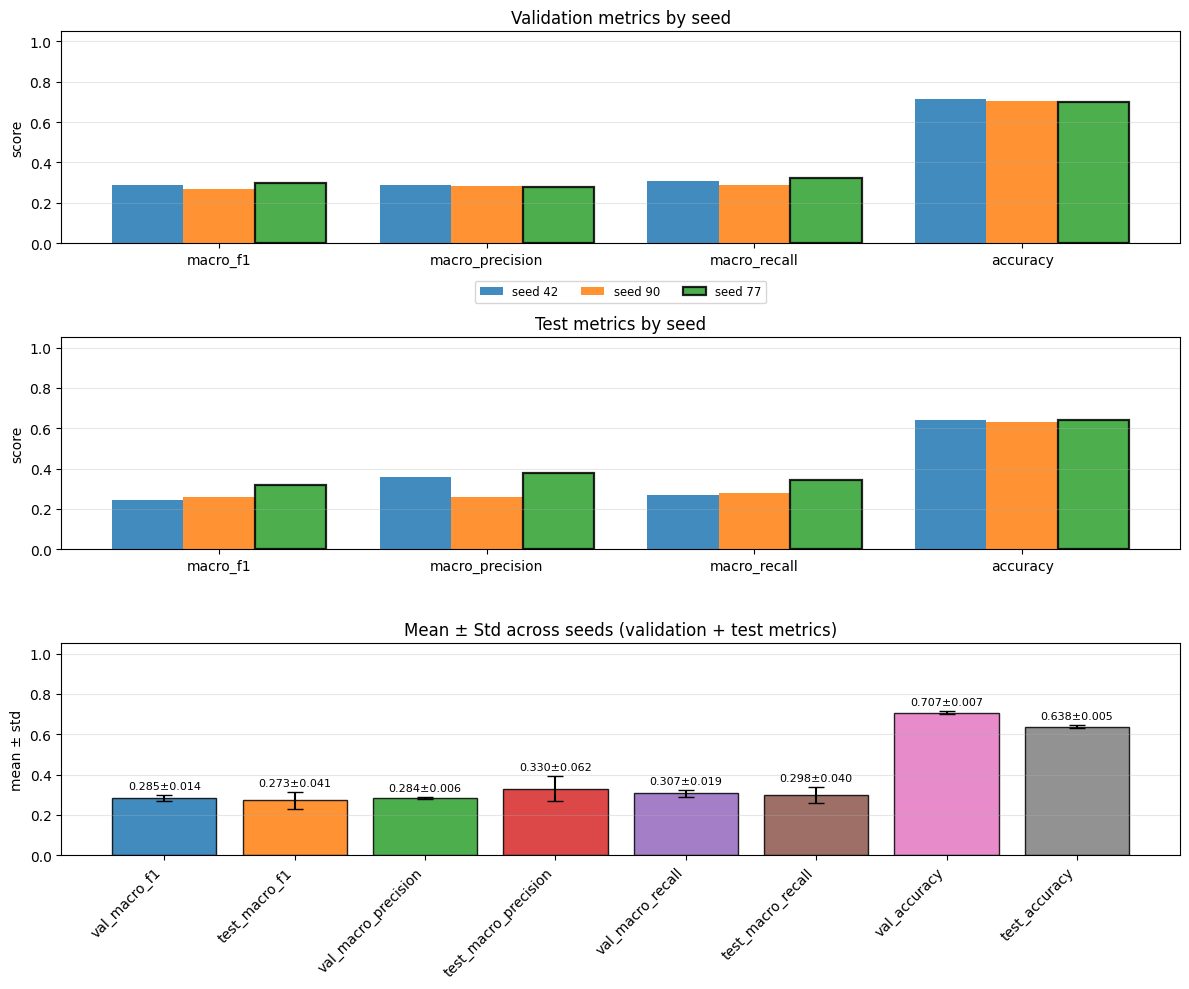

,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.294733,0.430556,0.300155,0.713333,0.297150,0.380503,0.305944,0.667857,42
1,0.394052,0.587733,0.397852,0.753333,0.345200,0.466691,0.342966,0.675000,90
2,0.479461,0.501299,0.486258,0.746667,0.356296,0.346529,0.372024,0.621429,77


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.389415,0.332882,0.506529,0.397908,0.394755,0.340312,0.737778,0.654762
std,0.092451,0.031438,0.078719,0.061942,0.093090,0.033120,0.021430,0.029088


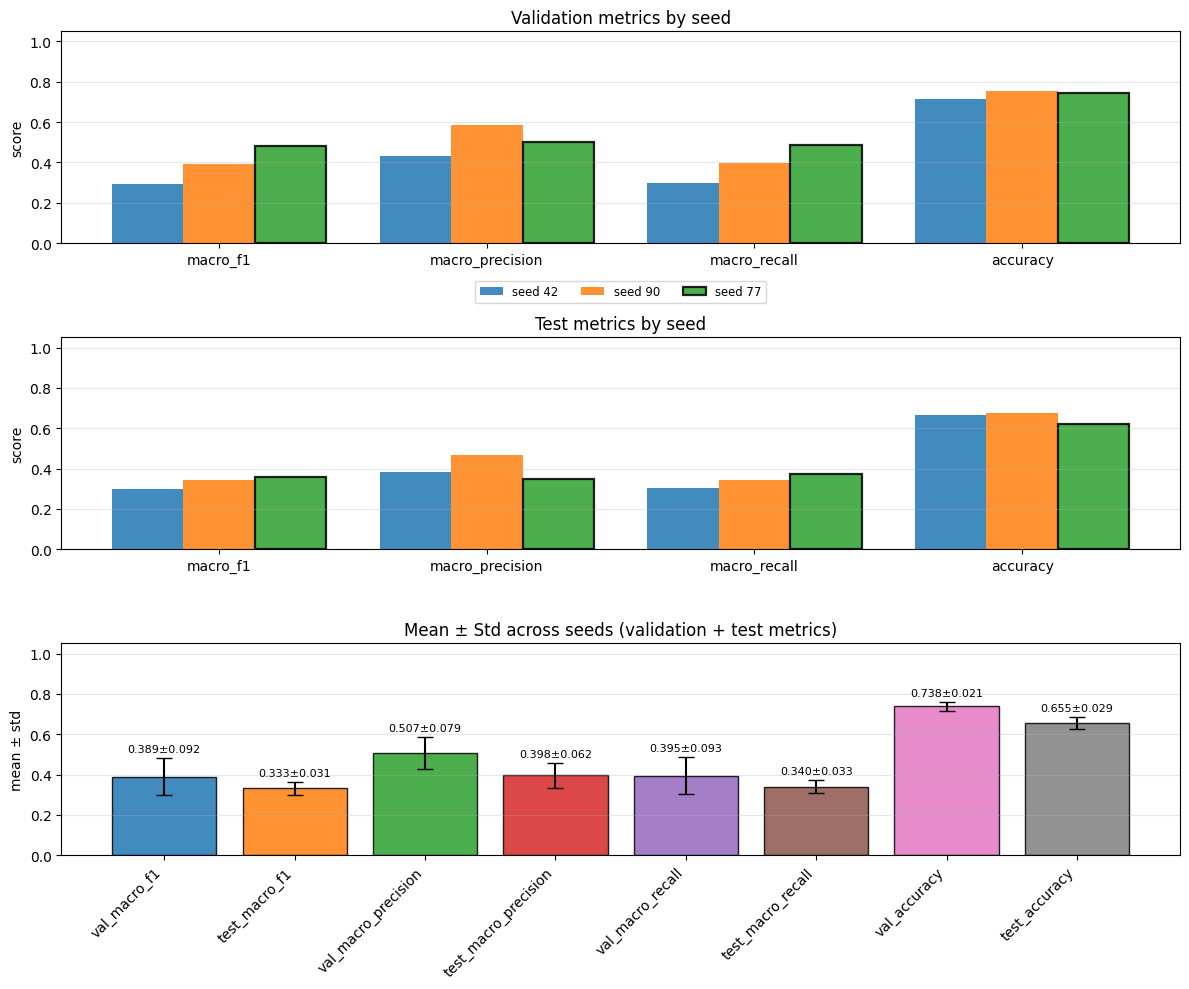

In [84]:
logs_base_no, logs_stacked_no = evaluation(models, dir='./weights/no_class_dict')
agg_base_no, best_run_base_no=mean_std(logs_base_no)
display(logs_base_no)
display(agg_base_no)
plot_summary_metrics(logs_base_no, agg_base_no, best_run_base_no)
agg_stacked_no, best_run_stacked_no=mean_std(logs_stacked_no)
display(logs_stacked_no)
display(agg_stacked_no)
plot_summary_metrics(logs_stacked_no, agg_stacked_no, best_run_stacked_no)


Plotting seed: 42
  Model: baseline
  Model: stacked

Plotting seed: 90
  Model: baseline
  Model: stacked

Plotting seed: 77
  Model: baseline
  Model: stacked


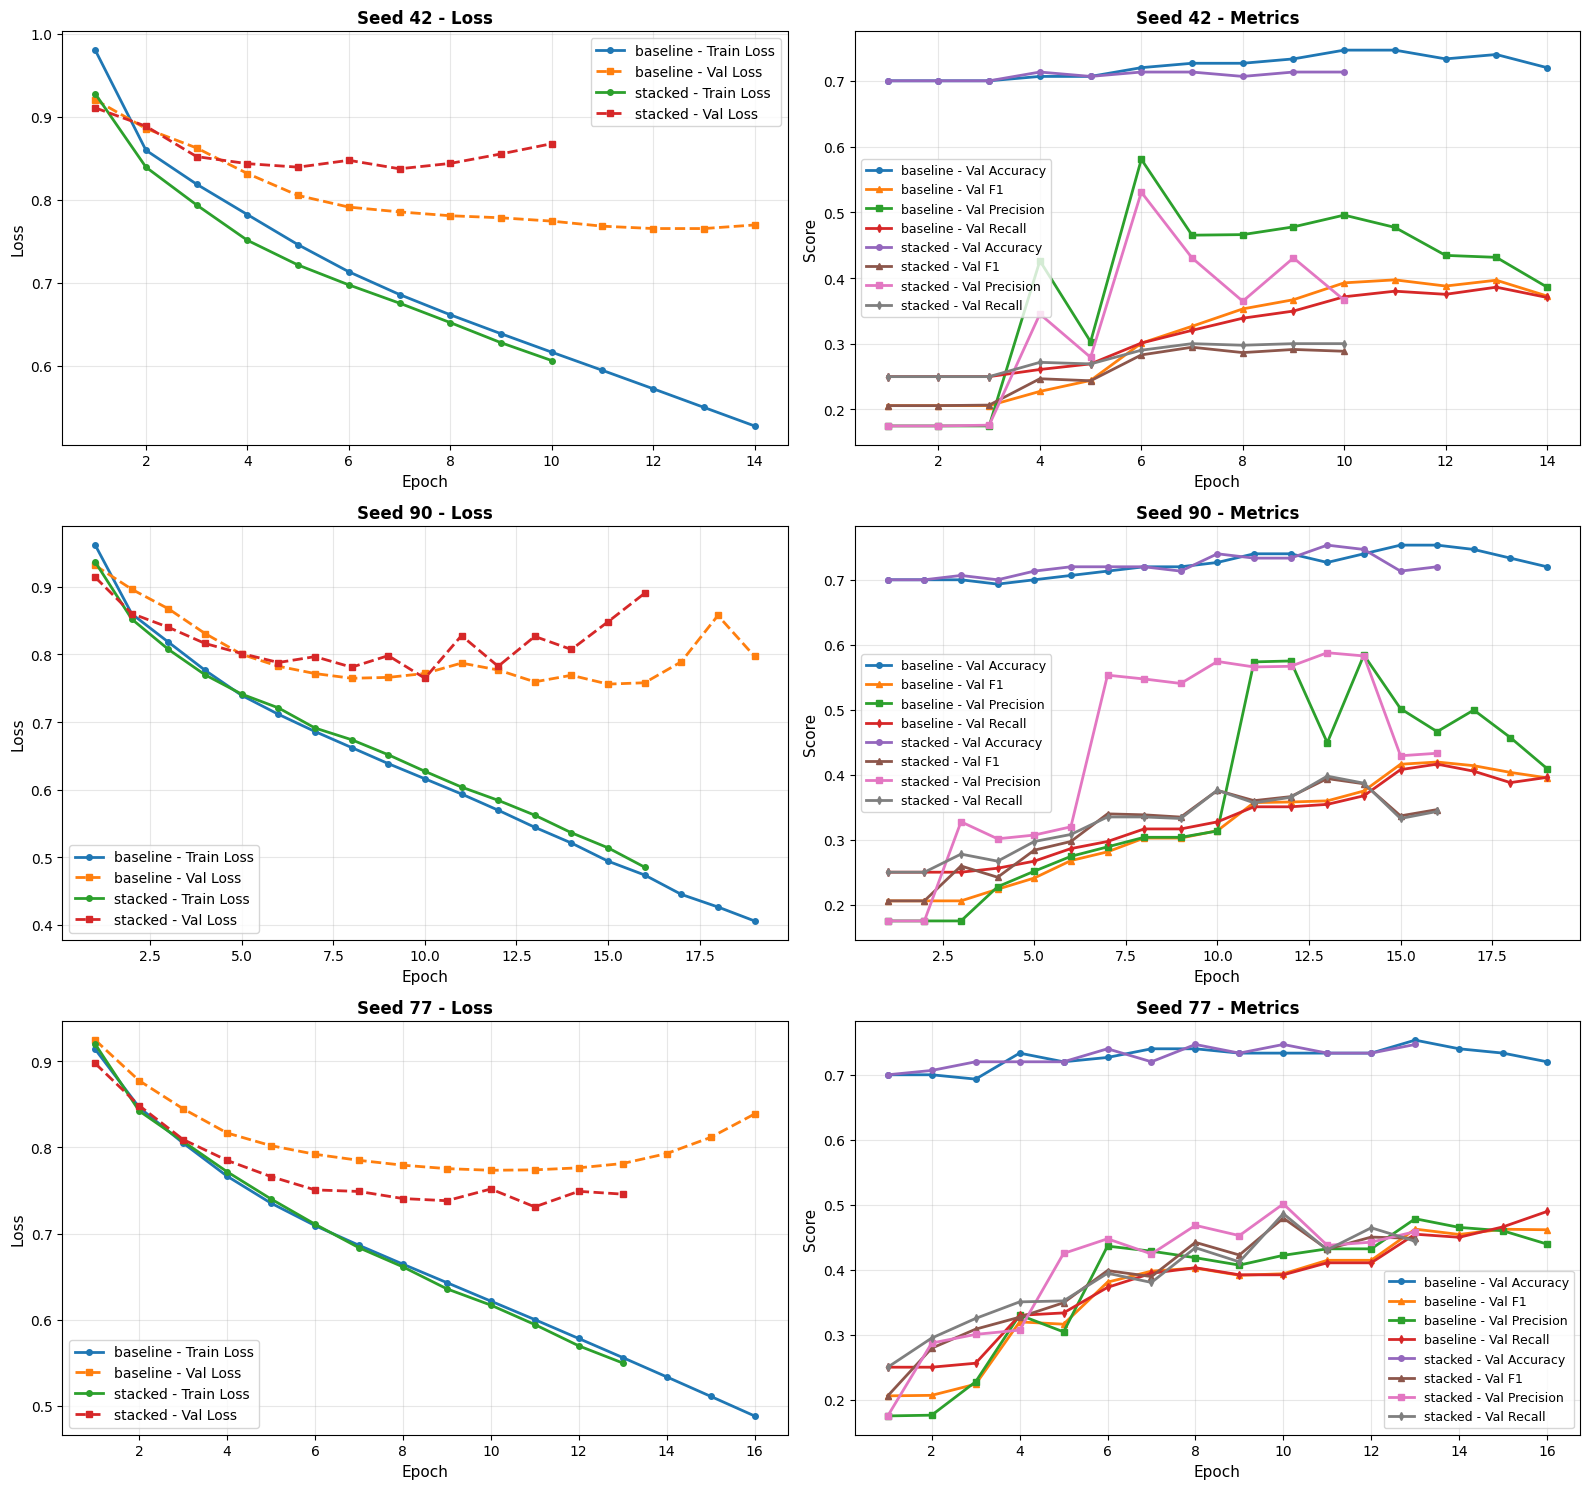

In [48]:
# Call once for all histories
plot_training_history(histories)

We see the f1 is lower and also the than the one obtained before but also the training gets stack for the first two or three epochs as it is not improving in the classification while the validation loss is reducing. This is problematic and the introduction of the class weights are not present. The training requires also less time.

## Embedding 

The embedding is done by using just the terms which are present in the tweets. However it was noticed that there are some terms in the test set which are not present in the training set but are present in the GLoVE vocabulary. For this reason, it could be useful to see whether using all the tokenz available in GLoVE in the vocabulary could be useful to improve the quality in the prediction. Let's check first the number of tokens in the test set which are in GLoVe but not in the training corpus

In [61]:
def check_glove_coverage(test_tokens, train_vocab, embedding_model):
    """
    Check how many tokens in the test set are in GLoVe but not in training corpus.
    Also check how many test tokens would be OOV if using GLoVe as vocabulary.
    
    Parameters:
    -----------
    test_tokens : set or list
        Unique tokens from the test set
    train_vocab : set or list
        Vocabulary from the training corpus
    embedding_model : gensim.models.keyedvectors.KeyedVectors
        Loaded embedding model (GLoVe, Word2Vec, or FastText)
    
    Returns:
    --------
    dict
        Dictionary containing:
        - 'in_glove_not_train': set of tokens in GLoVe but not in training
        - 'count': number of such tokens
        - 'oov_tokens': set of test tokens not in GLoVe (would be OOV)
        - 'oov_count': number of OOV tokens
        - 'total_test_tokens': total unique tokens in test set
        - 'coverage_percentage': percentage of test tokens in GLoVe but not in training
        - 'oov_percentage': percentage of test tokens that would be OOV with GLoVe
        - 'glove_coverage_percentage': percentage of test tokens covered by GLoVe
    """
    # Convert to sets for efficient operations
    test_set = set(test_tokens)
    train_set = set(train_vocab)
    # Extract vocabulary from the embedding model
    glove_set = set(embedding_model.key_to_index.keys())
    
    # Find tokens in test set that are in GLoVe but not in training
    in_glove_not_train = test_set.intersection(glove_set).difference(train_set)
    
    # Find tokens in test set that are NOT in GLoVe (OOV if using GLoVe)
    oov_tokens = test_set.difference(glove_set)
    
    # Calculate statistics
    count = len(in_glove_not_train)
    oov_count = len(oov_tokens)
    total_test = len(test_set)
    coverage_pct = (count / total_test * 100) if total_test > 0 else 0
    oov_pct = (oov_count / total_test * 100) if total_test > 0 else 0
    glove_coverage_pct = ((total_test - oov_count) / total_test * 100) if total_test > 0 else 0
    
    return {
        'in_glove_not_train': in_glove_not_train,
        'count': count,
        'oov_tokens': oov_tokens,
        'oov_count': oov_count,
        'total_test_tokens': total_test,
        'coverage_percentage': coverage_pct,
        'oov_percentage': oov_pct,
        'glove_coverage_percentage': glove_coverage_pct
    }


# Example usage:
# Assuming you have:
# - test_words: tokens from your test set
# - train_vocab: vocabulary from training corpus
# - embedding_model: loaded Gensim KeyedVectors model

result = check_glove_coverage(test_words, train_vocab, embedding_model)

print(f"Tokens in GLoVe but not in training: {result['count']}")
print(f"Total test tokens: {result['total_test_tokens']}")
print(f"Coverage: {result['coverage_percentage']:.2f}%")
print(f"\nOOV tokens (not in GLoVe): {result['oov_count']}")
print(f"OOV percentage: {result['oov_percentage']:.2f}%")
print(f"GLoVe coverage: {result['glove_coverage_percentage']:.2f}%")
print(f"\nSample tokens in GLoVe but not in training: {list(result['in_glove_not_train'])[:10]}")
print(f"Sample OOV tokens: {list(result['oov_tokens'])[:10]}")

Tokens in GLoVe but not in training: 433
Total test tokens: 2124
Coverage: 20.39%

OOV tokens (not in GLoVe): 114
OOV percentage: 5.37%
GLoVe coverage: 94.63%

Sample tokens in GLoVe but not in training: ['certificate', 'detest', 'perk', '315', 'cramp', 'inquisitor', 'kit', 'idc', 'rightfully', 'filibuster']
Sample OOV tokens: ['motherfúckers', 'idk', 'lesbicious', 'headchapter', 'mojassim80', 'cooooourse', 'experiencechapter', 'transwoman', 'superweapons', 'ns3m']


In [63]:
tokenizer = build_tokenizer(
    train_words=train_words,
    embedding_model=embedding_model,
    use_full_embed_model=True,
    oov_token=OOV_TOKEN,
    verbose=True
)

vocab_size = len(tokenizer.word_index) + 1 # +1 for padding at index 0
print(f"Final vocabulary size: {vocab_size}\n")

# Build embedding matrix
embedding_matrix, random_idxs = build_embedding_matrix(
    tokenizer=tokenizer,
    embedding_model=embedding_model,
    seed=SEED,
    verbose=True
)

Final vocabulary size: 400964



Building embedding matrix: 100%|██████████| 400963/400963 [00:00<00:00, 861920.70it/s]

Embedding Matrix Statistics:
	Shape: (400964, 50)
	Words from embedding model: 400000/400963 (99.76%)
	Random embeddings (OOV): 963


Retrain the model with the new vocabulary

In [64]:
# Convert train/val/test texts to sequences
X_train_sequences = texts_to_sequences(train_df['cleaned_lemm_tweet'].values, tokenizer.word_index)
X_val_sequences = texts_to_sequences(val_df['cleaned_lemm_tweet'].values, tokenizer.word_index)
X_test_sequences = texts_to_sequences(test_df['cleaned_lemm_tweet'].values, tokenizer.word_index)

X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_SEQ_LEN, padding='post')

print(f"X_train shape: {X_train_padded.shape}")
print(f"X_val shape: {X_val_padded.shape}")
print(f"X_test shape: {X_test_padded.shape}")

X_train shape: (2873, 63)
X_val shape: (150, 63)
X_test shape: (280, 63)


In [ ]:
import gc
import tensorflow as tf

load_weights=True

# Run this
clear_all_memory()

# Use the function
if load_weights is True:
    train_and_eval_seeds(models, X_train_padded,
                        y_train_cat, X_val_padded,
                        y_val_cat, class_weight_dict=class_weight_dict, 
                        dir='./weights/total_voc', load_weights=load_weights)
else:
    histories, results, f1_voc = train_and_eval_seeds(models, X_train_padded, y_train_cat, X_val_padded,
                                                   y_val_cat, class_weight_dict=class_weight_dict, dir='./weights/total_voc', load_weights=load_weights)



SEED: 42

Training: baseline (seed=42)

Model Architecture:


Model: "baseline_bidirectional_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │    20,048,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_36                │ (None, 128)            │        58,880 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,107,596 (76.70 MB)

 Trainable params: 20,107,596 (76.70 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │    20,048,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 63, 128)        │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,148,556 (76.86 MB)

 Trainable params: 20,148,556 (76.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.2168 - loss: 1.3701
  - val_f1: 0.2024 - val_precision: 0.3039 - val_recall: 0.3112
360/360 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - accuracy: 0.2360 - loss: 1.3650 - val_accuracy: 0.2400 - val_loss: 1.3652 - val_f1: 0.2024 - val_precision: 0.3039 - val_recall: 0.3112 - val_accuracy_sklearn: 0.2400
Epoch 2/40
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3207 - loss: 1.2940
  - val_f1: 0.3735 - val_precision: 0.3680 - val_recall: 0.4356
360/360 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.3488 - loss: 1.2873 - val_accuracy: 0.5333 - val_loss: 1.2203 - val_f1: 0.3735 - val_precision: 0.3680 - val_recall: 0.4356 - val_accuracy_sklearn: 0.5333
Epoch 3/40
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4296 - loss: 1.2148
  - val_f1: 0.4128 - val_precision: 0.3991 - val_recall: 0.4656
360/360 ━━━━━━━━━━━━━━━━━━━━ 28s 77ms/step - accuracy: 0.4574 - loss: 1.2263 - val_accuracy: 0.5933 - val_loss: 1.1263 - va

In [85]:
logs_base_no, logs_stacked_no = evaluation(models, dir='./weights/total_voc')
agg_base_no, best_run_base_no=mean_std(logs_base_no)
display(logs_base_no)
display(agg_base_no)
plot_summary_metrics(logs_base_no, agg_base_no, best_run_base_no)
agg_stacked_no, best_run_stacked_no=mean_std(logs_stacked_no)
display(logs_stacked_no)
display(agg_stacked_no)
plot_summary_metrics(logs_stacked_no, agg_stacked_no, best_run_stacked_no)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'weights/total_voc/weights_baseline_seed42.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

The model is actually a bit better here, it also interesting to investigate whether increasing the embedding dimension would improve the predictions' quality. It will be investigated if also not making the layer trainable improves the quality of the predicitons.

In [ ]:
EMBEDDING_DIMENSION=200

embedding_model = load_embedding_model("glove", EMBEDDING_DIMENSION)

tokenizer = build_tokenizer(
    train_words=train_words,
    embedding_model=embedding_model,
    use_full_embed_model=False,
    oov_token=OOV_TOKEN,
    verbose=True
)

vocab_size = len(tokenizer.word_index) + 1 # +1 for padding at index 0
print(f"Final vocabulary size: {vocab_size}\n")

# Build embedding matrix
embedding_matrix, random_idxs = build_embedding_matrix(
    tokenizer=tokenizer,
    embedding_model=embedding_model,
    seed=SEED,
    verbose=True
)

# Convert train/val/test texts to sequences
X_train_sequences = texts_to_sequences(train_df['cleaned_lemm_tweet'].values, tokenizer.word_index)
X_val_sequences = texts_to_sequences(val_df['cleaned_lemm_tweet'].values, tokenizer.word_index)
X_test_sequences = texts_to_sequences(test_df['cleaned_lemm_tweet'].values, tokenizer.word_index)

X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=MAX_SEQ_LEN, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_SEQ_LEN, padding='post')

print(f"X_train shape: {X_train_padded.shape}")
print(f"X_val shape: {X_val_padded.shape}")
print(f"X_test shape: {X_test_padded.shape}")

Tokenizer doesn't contain 391818 words from the embedding model (they were not in the train set).
Final vocabulary size: 9146



Building embedding matrix: 100%|██████████| 9145/9145 [00:00<00:00, 490937.03it/s]

Embedding Matrix Statistics:
	Shape: (9146, 200)
	Words from embedding model: 8182/9145 (89.47%)
	Random embeddings (OOV): 963
X_train shape: (2873, 63)
X_val shape: (150, 63)
X_test shape: (280, 63)


In [ ]:
import gc
import tensorflow as tf

load_weights=True

# Run this
clear_all_memory()

# Use the function
if load_weights is True:
    train_and_eval_seeds(models, X_train_padded,
                        y_train_cat, X_val_padded,
                        y_val_cat, class_weight_dict=class_weight_dict, 
                        dir='./weights/emb_200', load_weights=load_weights)
else:
    histories, results, f1_voc = train_and_eval_seeds(models, X_train_padded, y_train_cat, X_val_padded,
                                                   y_val_cat, class_weight_dict=class_weight_dict, 
                                                   dir='./weights/emb_200', load_weights=load_weights)


SEED: 42

Training: baseline (seed=42)

Model Architecture:


Model: "baseline_bidirectional_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 200)        │     1,829,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_20                │ (None, 128)            │       135,680 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,965,396 (7.50 MB)

 Trainable params: 1,965,396 (7.50 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 200)        │     1,829,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 63, 128)        │       135,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,006,356 (7.65 MB)

 Trainable params: 2,006,356 (7.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3298 - loss: 1.3745
  - val_f1: 0.2307 - val_precision: 0.3318 - val_recall: 0.3361
360/360 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.2725 - loss: 1.3721 - val_accuracy: 0.2467 - val_loss: 1.3595 - val_f1: 0.2307 - val_precision: 0.3318 - val_recall: 0.3361 - val_accuracy_sklearn: 0.2467
Epoch 2/40
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3700 - loss: 1.2734
  - val_f1: 0.4251 - val_precision: 0.4399 - val_recall: 0.5006
360/360 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.4184 - loss: 1.2682 - val_accuracy: 0.5333 - val_loss: 1.1943 - val_f1: 0.4251 - val_precision: 0.4399 - val_recall: 0.5006 - val_accuracy_sklearn: 0.5333
Epoch 3/40
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5286 - loss: 1.1503
  - val_f1: 0.3721 - val_precision: 0.3981 - val_recall: 0.4562
360/360 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.5367 - loss: 1.1583 - val_accuracy: 0.4600 - val_loss: 1.2236 - va

In [ ]:
logs_base_no, logs_stacked_no = evaluation(models, dir='./weights/emb_200')
agg_base_no, best_run_base_no=mean_std(logs_base_no)
display(logs_base_no)
display(agg_base_no)
plot_summary_metrics(logs_base_no, agg_base_no, best_run_base_no)
agg_stacked_no, best_run_stacked_no=mean_std(logs_stacked_no)
display(logs_stacked_no)
display(agg_stacked_no)
plot_summary_metrics(logs_stacked_no, agg_stacked_no, best_run_stacked_no)

baseline
[0.4472014921180661, 0.4150378700302275, 0.39419687429957]
  Mean F1: 0.4188 ± 0.0218
stacked
[0.3460837955416992, 0.44999354558178084, 0.3700406567427844]
  Mean F1: 0.3887 ± 0.0444


It seems it is a bit higher so it could be useful trying also with higher embedding dimensions in the future. It is however necessary to say that for a small change in the f1 macro score, we have had for times the number of parameters while before we had nearly 40 times the number of parameters, so even though the performances are slightly better it is necessary to say that it is better to have a lighter model.

A last check which could be done on the embedding is checking that if the embedding is totally random the model performs better.

In [59]:
load_weights=False

# Run this
clear_all_memory()

# Use the function
if load_weights is True:
    train_and_eval_seeds(models, X_train_padded,
                        y_train_cat, X_val_padded,
                        y_val_cat, class_weight_dict=class_weight_dict, 
                        dir='./weights/rand_emb', load_weights=load_weights)
else:
    histories, results, f1_voc = train_and_eval_seeds(models, X_train_padded, y_train_cat, X_val_padded,
                                                   y_val_cat, class_weight_dict=class_weight_dict, dir='./weights/rand_emb',
                                                    load_weights=load_weights, tot=True)



SEED: 42


Building embedding matrix: 100%|██████████| 9145/9145 [00:00<00:00, 185151.50it/s]

Embedding Matrix Statistics:
	Shape: (9146, 50)
	Words from embedding model: 0/9145 (0.00%)
	Random embeddings (OOV): 9145

Training: baseline (seed=42)

Model Architecture:


Model: "baseline_bidirectional_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding (Embedding)   │ (None, 63, 50)         │       457,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Embedding Matrix Statistics:
	Shape: (9146, 50)
	Words from embedding model: 0/9145 (0.00%)
	Random embeddings (OOV): 9145

Training: baseline (seed=77)
Epoch 1/40


359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4148 - loss: 1.3866
  - val_f1: 0.1715 - val_precision: 0.2712 - val_recall: 0.2895
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.3724 - loss: 1.3832 - val_accuracy: 0.1800 - val_loss: 1.4342 - val_f1: 0.1715 - val_precision: 0.2712 - val_recall: 0.2895 - val_accuracy_sklearn: 0.1800
Epoch 2/40
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2956 - loss: 1.3584
  - val_f1: 0.1893 - val_precision: 0.2773 - val_recall: 0.2990
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3223 - loss: 1.3573 - val_accuracy: 0.2067 - val_loss: 1.4408 - val_f1: 0.1893 - val_precision: 0.2773 - val_recall: 0.2990 - val_accuracy_sklearn: 0.2067
Epoch 3/40
358/360 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3185 - loss: 1.3328
  - val_f1: 0.1836 - val_precision: 0.2657 - val_recall: 0.2825
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.3456 - loss: 1.3307 - val_accuracy: 0.2000 - val_loss: 1.4485 - val_f1: 0.1836 -

Building embedding matrix: 100%|██████████| 9145/9145 [00:00<00:00, 190592.39it/s]

Embedding Matrix Statistics:
	Shape: (9146, 50)
	Words from embedding model: 0/9145 (0.00%)
	Random embeddings (OOV): 9145

Training: stacked (seed=77)
Epoch 1/40


360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2386 - loss: 1.4004
  - val_f1: 0.1169 - val_precision: 0.2659 - val_recall: 0.2204
360/360 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.2496 - loss: 1.3908 - val_accuracy: 0.1333 - val_loss: 1.4333 - val_f1: 0.1169 - val_precision: 0.2659 - val_recall: 0.2204 - val_accuracy_sklearn: 0.1333
Epoch 2/40
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2316 - loss: 1.3640
  - val_f1: 0.1601 - val_precision: 0.2815 - val_recall: 0.2475
360/360 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.2680 - loss: 1.3613 - val_accuracy: 0.1733 - val_loss: 1.4477 - val_f1: 0.1601 - val_precision: 0.2815 - val_recall: 0.2475 - val_accuracy_sklearn: 0.1733
Epoch 3/40
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3124 - loss: 1.3355
  - val_f1: 0.1980 - val_precision: 0.2751 - val_recall: 0.2712
360/360 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.3404 - loss: 1.3255 - val_accuracy: 0.2200 - val_loss: 1.4550 - val_f1: 0.198

,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.358134,0.355113,0.370005,0.58,0.340746,0.345865,0.339961,0.542857,42
1,0.327684,0.332753,0.324741,0.60,0.354313,0.372469,0.348873,0.589286,90
2,0.202257,0.270022,0.316563,0.22,0.252621,0.318141,0.346472,0.282143,77


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.296025,0.315893,0.319296,0.345491,0.337103,0.345102,0.466667,0.471429
std,0.082621,0.055214,0.044113,0.027166,0.028786,0.004611,0.213854,0.165562


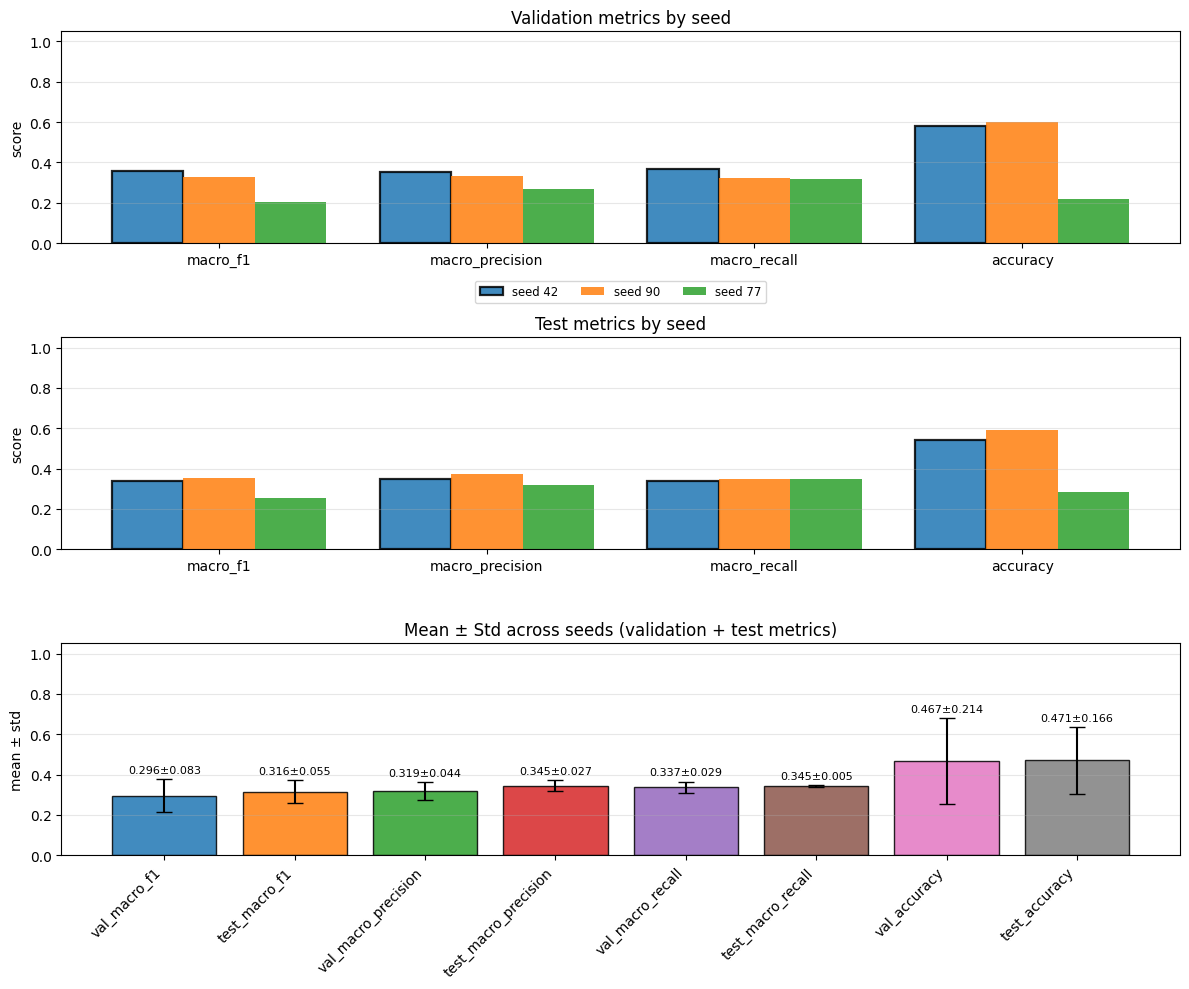

,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_accuracy,seed
0,0.393694,0.383567,0.421946,0.586667,0.378568,0.375503,0.415961,0.532143,42
1,0.386250,0.529208,0.357479,0.640000,0.404297,0.494227,0.387369,0.632143,90
2,0.264739,0.301637,0.316900,0.360000,0.339341,0.371246,0.418232,0.400000,77


,val_macro_f1,test_macro_f1,val_macro_precision,test_macro_precision,val_macro_recall,test_macro_recall,val_accuracy,test_accuracy
mean,0.348228,0.374069,0.404804,0.413659,0.365442,0.407187,0.528889,0.521429
std,0.072399,0.032711,0.115262,0.069807,0.052974,0.017201,0.148673,0.116442


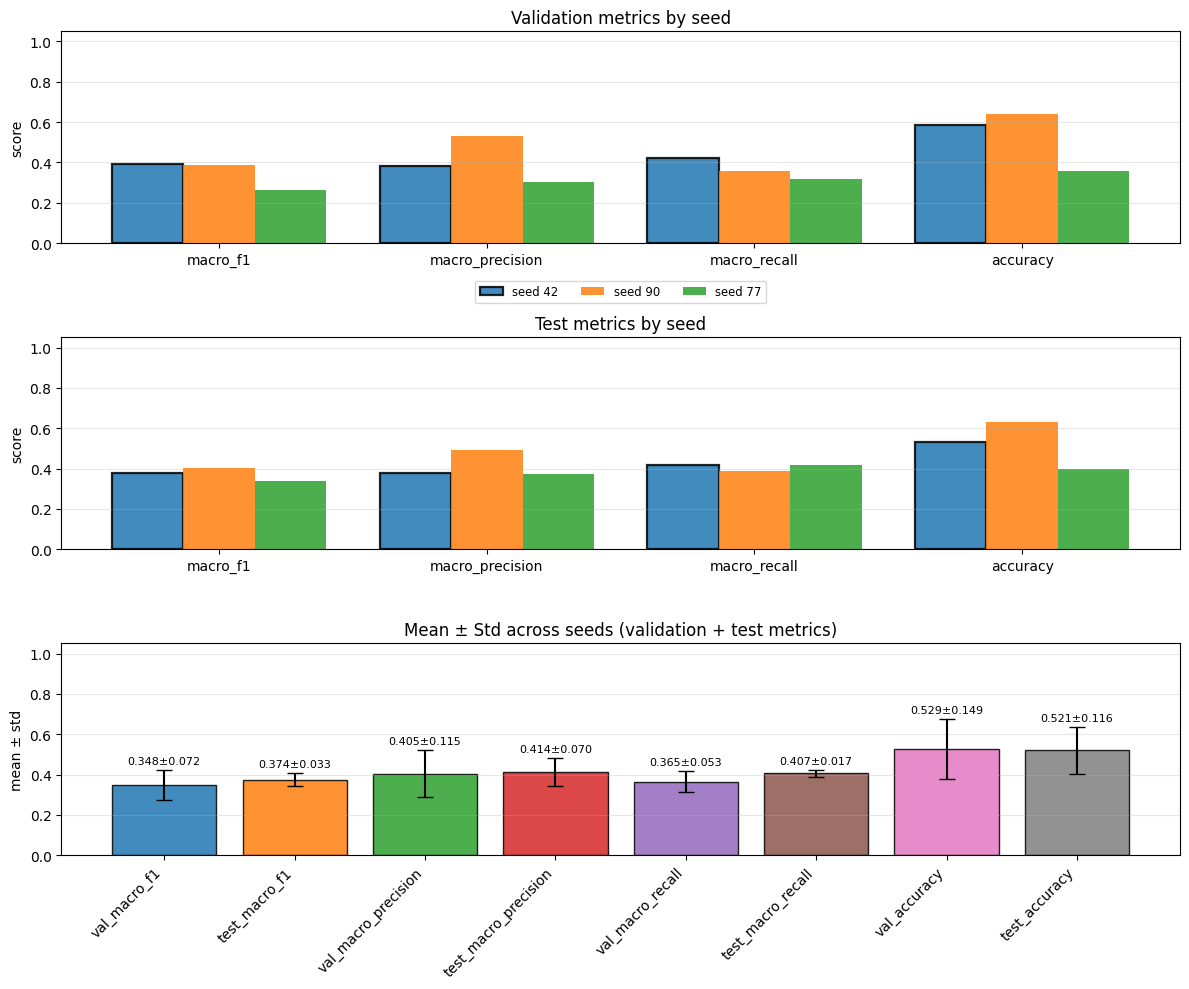

In [86]:
logs_base_no, logs_stacked_no = evaluation(models, dir='./weights/rand_emb')
agg_base_no, best_run_base_no=mean_std(logs_base_no)
display(logs_base_no)
display(agg_base_no)
plot_summary_metrics(logs_base_no, agg_base_no, best_run_base_no)
agg_stacked_no, best_run_stacked_no=mean_std(logs_stacked_no)
display(logs_stacked_no)
display(agg_stacked_no)
plot_summary_metrics(logs_stacked_no, agg_stacked_no, best_run_stacked_no)

GLoVE is still better.

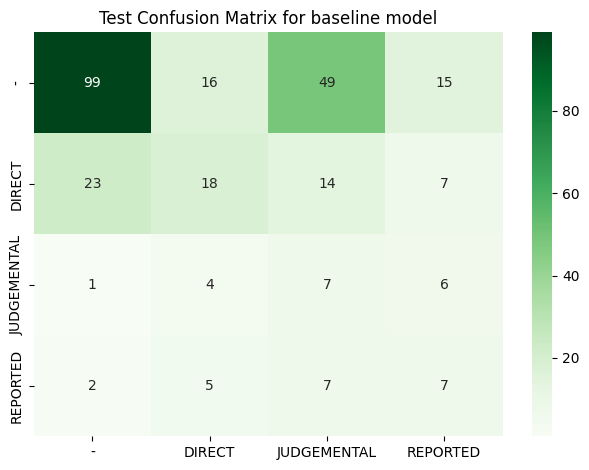

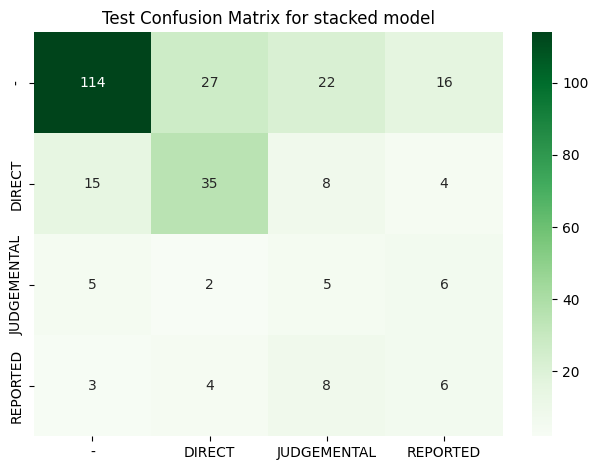

In [101]:
import seaborn as sns
def plot_conf_matrix(models, model, best_run, dir='./'):
    best_seed=int(best_run['seed'])
    current_model = models[model](seed=best_seed)
    current_model.load_weights(f'{dir}/weights_{model}_seed{best_seed}.weights.h5') 

    y_pred_probs = current_model.predict(X_test_padded, verbose=0)
    y_test_pred = np.argmax(y_pred_probs, axis=-1)   
    # Convert one-hot to class indices if needed
    if len(y_test_cat.shape) > 1:
        y_test_true = np.argmax(y_test_cat, axis=-1)
    else:
        y_test_true = y_test_cat
    
    label_names=['-', 'DIRECT', 'JUDGEMENTAL','REPORTED']
    test_cm= confusion_matrix(y_test_true, y_test_pred)
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Test Confusion Matrix for {model} model')
    plt.tight_layout()
    plt.show() 

plot_conf_matrix(models,'baseline', best_run_base, dir='./weights/base')
plot_conf_matrix(models, 'stacked', best_run_stacked, dir='./weights/base')

In [89]:
print(best_run_base['seed'])

42.0


# [Task 8 - 0.5 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is **not a copy-paste** of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.


# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...
* You can upload **model weights** in a cloud repository and report the link in the report.

## Bonus Points
Bonus points are arbitrarily assigned based on significant contributions such as:
- Outstanding error analysis
- Masterclass code organization
- Suitable extensions

**Note**: bonus points are only assigned if all task points are attributed (i.e., 6/6).

**Possible Suggestions for Bonus Points:**
- **Try other preprocessing strategies**: e.g., but not limited to, explore techniques tailored specifically for tweets or  methods that are common in social media text.
- **Experiment with other custom architectures or models from HuggingFace**
- **Explore Spanish tweets**: e.g., but not limited to, leverage multilingual models to process Spanish tweets and assess their performance compared to monolingual models.

# FAQ

Please check this frequently asked questions before contacting us

### Trainable Embeddings

You are **free** to define a trainable or non-trainable Embedding layer to load the GloVe embeddings.

### Model architecture

You **should not** change the architecture of a model (i.e., its layers).

However, you are **free** to play with their hyper-parameters.


### Neural Libraries

You are **free** to use any library of your choice to implement the networks (e.g., Keras, Tensorflow, PyTorch, JAX, etc...)

### Robust Evaluation

Each model is trained with at least 3 random seeds.

Task 5 requires you to compute the average performance over the 3 seeds and its corresponding standard deviation.

### Expected Results

Task 2 leaderboard reports around 40-50 F1-score.
However, note that they perform a hierarchical classification.

That said, results around 30-40 F1-score are **expected** given the task's complexity.

### Model Selection for Analysis

To carry out the error analysis you are **free** to either

* Pick examples or perform comparisons with an individual seed run model (e.g., Baseline seed 1337)
* Perform ensembling via, for instance, majority voting to obtain a single model.

### Error Analysis

Some topics for discussion include:
   * Precision/Recall curves.
   * Confusion matrices.
   * Specific misclassified samples.


# The End

Feel free to reach out for questions/doubts!